# Polar MHW Heat Budget: Arctic Circumpolar Analysis

Reproduce the analyses from Neil for the Southern Ocean to the full
Arctic Ocean north of 60°N, using **10×10 grid-cell boxes** (2.5°×2.5° each at 0.25° resolution).
Needs some heavy adaptation to deal with the North pole. The 2.5° x 2.5° is not a good approach 
for the Arctic; rather needs some lat-dependent size.

For every valid ocean box (≥75% ocean cells):
1. Detect MHW events using Hobday et al. (2016) threshold exceedance.
2. Separate onset (start→peak) from decline (peak→end).
3. Compute mean mixed-layer heat budget anomalies for each phase.
4. Save composites to NetCDF for spatial mapping.

The ACCESS-OM2 grid seam at ~80°E is handled with a two-slice concatenation.  
Pre-compute is split into latitude bands to keep Dask graphs tractable.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import pandas as pd
# import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import pickle
# Benjy's packages
import ultraplot as uplt
from pathlib import Path

%matplotlib inline

In [2]:
from dask.distributed import Client

# processes=True + threads_per_worker=1 avoids netCDF4/HDF5 thread-safety races
# when many workers read chunks from the same open_mfdataset files concurrently.
client = Client(processes=True, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 64
Total threads: 64,Total memory: 124.79 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44011,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46789,Total threads: 1
Dashboard: http://127.0.0.1:45521/status,Memory: 1.95 GiB
Nanny: tcp://127.0.0.1:43375,


## 1. Configuration

In [3]:
def map_lon_to_ds(lon_e, lon_coord_min=-280.0, lon_coord_max=80.0):
    """Map standard longitudes to the ACCESS-OM2 grid convention."""
    lonmin, lonmax = lon_coord_min, lon_coord_max
    if 0.0 <= lonmin and lonmax <= 360.0:
        return lon_e % 360.0
    if -180.0 <= lonmin and lonmax <= 180.0:
        return ((lon_e + 180.0) % 360.0) - 180.0
    if lonmax <= 100.0 and lonmin < -180.0:  # ACCESS-style (-280 to 80)
        return lon_e if lon_e <= lonmax else lon_e - 360.0
    return lon_e


# ── Domain ────────────────────────────────────────────────────────────────────
LAT_MIN      = 60.0   # southernmost latitude
LAT_MAX      = 90.0   # All the way to the pole
# BOX_DEG_LAT  =   2.5   # box size in degrees (10 grid cells at 0.25°)
BOX_SIZE  =   20      # box size in degrees (10 grid cells at 0.25°)
MIN_OCN_FRAC =  0.75  # minimum ocean cell fraction to include a box

# Set TEST_MODE = True to run only ~6 boxes overlapping the NB02 Drake Passage
# transect — useful for validating results against notebook 02 before a full PBS run.
TEST_MODE = False

# ── Data ──────────────────────────────────────────────────────────────────────
base         = Path('/vfast/brichaud/projects/HeatBudgetMHW_Athanase/data/extern/mlt_mld_daily/')
START_OUTPUT = 357     # 2010
END_OUTPUT   = 366     # 2019
outputs      = list(range(START_OUTPUT, END_OUTPUT + 1))
OUTPUT_DIR   = Path('/vfast/brichaud/projects/HeatBudgetMHW_Athanase/data/interim/')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── MHW detection ─────────────────────────────────────────────────────────────
MIN_DUR = 5
MAX_GAP = 2

# ── Dask / I/O ────────────────────────────────────────────────────────────────
chunks2D    = {'time': 365, 'yt_ocean': 216, 'xt_ocean': 20}
SEC_PER_DAY = 86400.0

# ── Budget terms ──────────────────────────────────────────────────────────────
TERM_MAP = {
    'MLT tendency'   : 'mlt_tendency',
    'Surface Flux'   : 'surf_to_ML',
    'Advection'      : 'advection',
    'Vertical mixing': 'vert_mixing',
    'Entrainment'    : 'entrainment',
}
BUDGET_TERMS  = list(TERM_MAP.keys())
SEASONS       = ['DJF', 'MAM', 'JJA', 'SON']
SEASON_COLORS = {'DJF': 'tab:red', 'MAM': 'tab:orange',
                 'JJA': 'tab:blue', 'SON': 'tab:green'}

In [4]:
# Load the lat-lon tripolar grid coordinates
ds_mesh = xr.open_dataset(base.joinpath('../meshgrid_access-om2_025_60N.nc'))

## 2. Generate circumpolar boxes

In [56]:
# Generate a mask first to remove land
mask_file  = base.joinpath('ocean_daily_mlt_output357.nc')
mask_month = (
    xr.open_dataset(mask_file, decode_times=False)
    .isel(time=slice(0, 31))
    .assign_coords({'geolat_t':ds_mesh.geolat_t, 'geolon_t':ds_mesh.geolon_t})
    .sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
)
# Divide T by the nominal density, get non-null values, do a mean over the 31 days to have a mask.
ocean_full = (mask_month['temp_in_mld'] / 1035).notnull().mean('time').compute()
print(f"Mask computed from {mask_file}")

def generate_tiles_boxes(ds_mesh, da_mask, box_size=20, ratio_gc=0.75):
    # """
    # Tile the full circumpolar domain with tiles of size box_size × box_size.

    # Tiles are defined based on the ACCESS-OM2 tripolar grid. 
    # """
    # Create arrays X and Y of increasing integers repeating each one 20 times.
    # Size those X and Y to match the grid dimensions
    x_grid=np.repeat(np.arange(0,np.ceil(ds_mesh.xt_ocean.size/box_size), dtype=int),box_size)[:ds_mesh.xt_ocean.size]
    y_grid=np.repeat(np.arange(0,np.ceil(ds_mesh.yt_ocean.size/box_size), dtype=int),box_size)[:ds_mesh.yt_ocean.size]
    # Create a mesh with those two arrays
    xx, yy = np.meshgrid(x_grid, y_grid)
    # Create a dataarray with values corresponding to an identifier for each tile
    nbox = xr.DataArray((xx + yy*(x_grid.max()+1)),dims=ds_mesh.dims)
    # Mask that da where there is land and no ice
    nbox = nbox.where(da_mask)
    nbox = nbox.assign_coords({'x':('xt_ocean',np.arange(0,len(nbox.xt_ocean))),
                               'y':('yt_ocean',np.arange(0,len(nbox.yt_ocean)))})
    # nbox.to_dataset(name='TileNumber').to_netcdf(Path2ice.joinpath('Tiles_access-om2_025_20x20_4HB.nc'))
    # Count the number of unmasked grid cells in each tile, by looping
    count=dict()
    for i,val in enumerate(np.unique(nbox.values)):
        if not np.isnan(val):
            count[int(val)] = (nbox == val).values.sum()
        
    # Further filter by keeping tiles with more than ratio_gc (75% by default)
    ngcmin = box_size * box_size * ratio_gc
    # Loop over count values and create boolean
    bool_bigtiles = [val>=ngcmin for val in count.values()]
    # Retrieve the list of the tile identifiers
    id_tiles_all = np.array([item for item in count.items()])
    # Only keep the tiles with more than ratio_gc grid cells
    id_tiles2keep = id_tiles_all[bool_bigtiles,0]
    tiles = nbox.where(nbox.isin(id_tiles2keep))

    # Calculate the average latitude and longitude for each tile
    boxes = []
    # Loop over tiles
    for ind, nb in enumerate(np.unique(tiles)):
        if ~np.isnan(nb):
            # Extract only grid cells with the identifier nb
            gcs = tiles.where(tiles==nb, drop=True)
            # Get the mean of the latitude
            lat_box = gcs.geolat_t.where(gcs==nb).mean(dim=['xt_ocean','yt_ocean'],skipna=True)
            # Because the ACCESS grid is defined from -280 to 80, there is no dateline issue, in theory.
            lon_gcs = gcs.geolon_t.where(gcs==nb)
            longeo_gcs = lon_gcs % 360 # Also convert to 0-360 standard coordinates.
            lon_box = lon_gcs.mean(dim=['xt_ocean','yt_ocean'],skipna=True)
            x_center = gcs.x.min() + box_size / 2
            y_center = gcs.y.min() + box_size / 2
    
        boxes.append({
            'lon_geo_min': longeo_gcs.min().values,
            'lon_geo_max': longeo_gcs.max().values,
            'lon_min_ds' : gcs.geolon_t.min().values,
            'lon_max_ds' : gcs.geolon_t.max().values,
            'lat_min'    : gcs.geolat_t.min().values,
            'lat_max'    : gcs.geolat_t.max().values,
            'lon_center' : lon_box.values,
            'lat_center' : lat_box.values,
            'x_center'   : x_center.values,
            'x_min'      : gcs.x.min().values,
            'x_max'      : gcs.x.max().values,
            'y_center'   : y_center.values,
            'y_min'      : gcs.y.min().values,
            'y_max'      : gcs.y.max().values,
            'seam'       : (gcs.geolon_t.min() > gcs.geolon_t.max()).values,  # straddles the -280/80 seam. Should never be true.
            'ocean_frac' : 1 - (gcs.isnull().sum().values / 400),
        })
    return tiles, boxes

def _box_slice(da, box):
    """
    Slice a DataArray or Dataset to a box, handling the ACCESS-OM2 seam at ~80°E.

    For the one seam-straddling box, the two non-contiguous parts of the grid
    are concatenated along xt_ocean.  Empty parts (if 80° is not an exact grid
    point) are dropped before concat.
    """
    return da.sel(
        x=slice(box['x_min'], box['x_max']), 
        y=slice(box['y_min'], box['y_max'])
    )

da_tiles, all_boxes = generate_tiles_boxes(ds_mesh, ocean_full, box_size=BOX_SIZE, ratio_gc=MIN_OCN_FRAC)
n_y = int(len(da_tiles.y) / BOX_SIZE)
n_x = int(len(da_tiles.x) / BOX_SIZE)
print(f"Valid boxes: {len(all_boxes)}")
print(f"Seam-straddling boxes: {sum(b['seam'] for b in all_boxes)}")

Mask computed from /vfast/brichaud/projects/HeatBudgetMHW_Athanase/data/extern/mlt_mld_daily/ocean_daily_mlt_output357.nc
Valid boxes: 402
Seam-straddling boxes: 0


In [6]:
# #NOTE: This won't work for the Arctic, because of the Northpole. Need to rework this
# # approach, probably by using 20 by 20 grid boxes, instead of 2.5° by 2.5°.
# def generate_circumpolar_boxes(lat_min, lat_max, box_deg):
#     """
#     Tile the full circumpolar domain with boxes of size box_deg × box_deg.

#     Boxes are defined in geographic longitude (0–360°) and converted to the
#     ACCESS-OM2 xt_ocean convention with map_lon_to_ds.  The one box that
#     straddles the grid seam at ~80°E (where xt_ocean jumps from ~80 to ~-280)
#     is flagged; _box_slice handles it with a two-part concatenation.
#     """
#     boxes = []
#     lat = lat_min
#     while round(lat, 6) < lat_max:
#         lon_geo = 0.0
#         while round(lon_geo, 6) < 360.0:
#             lon_max  = lon_geo + box_deg
#             lds_min = map_lon_to_ds(lon_geo)
#             lds_max = map_lon_to_ds(lon_max)
#             boxes.append({
#                 'lon_geo_min': lon_geo,
#                 'lon_geo_max': lon_max,
#                 'lon_min_ds' : lds_min,
#                 'lon_max_ds' : lds_max,
#                 'lat_min'    : lat,
#                 'lat_max'    : lat + box_deg,
#                 'lon_center' : lon_geo + box_deg / 2,
#                 'lat_center' : lat    + box_deg / 2,
#                 'seam'       : lds_min > lds_max,  # straddles the -280/80 seam
#                 'ocean_frac' : np.nan,
#             })
#             lon_geo = round(lon_geo + box_deg, 6)
#         lat = round(lat + box_deg, 6)
#     return boxes


# def _box_slice(da, box):
#     """
#     Slice a DataArray or Dataset to a box, handling the ACCESS-OM2 seam at ~80°E.

#     For the one seam-straddling box, the two non-contiguous parts of the grid
#     are concatenated along xt_ocean.  Empty parts (if 80° is not an exact grid
#     point) are dropped before concat.
#     """
#     lat_kw = dict(yt_ocean=slice(box['lat_min'], box['lat_max']))
#     if box['seam']:
#         p1 = da.sel(xt_ocean=slice(box['lon_min_ds'], 80.0), **lat_kw)
#         p2 = da.sel(xt_ocean=slice(-280.0, box['lon_max_ds']), **lat_kw)
#         parts = [p for p in (p1, p2) if p.sizes.get('xt_ocean', 0) > 0]
#         return xr.concat(parts, dim='xt_ocean') if len(parts) > 1 else parts[0]
#     return da.sel(
#         xt_ocean=slice(box['lon_min_ds'], box['lon_max_ds']), **lat_kw
#     )


# all_boxes = generate_circumpolar_boxes(LAT_MIN, LAT_MAX, BOX_DEG_LAT)
# n_lat = int((LAT_MAX - LAT_MIN) / BOX_DEG_LAT)
# n_lon = int(360.0 / BOX_DEG_LAT)
# print(f"Candidate boxes: {len(all_boxes)}  ({n_lon} lon × {n_lat} lat bands)")
# print(f"Seam-straddling boxes: {sum(b['seam'] for b in all_boxes)}")

## 3. Land mask and box filtering

Ocean fraction is derived from the fraction of non-NaN cells in `temp_in_mld`
averaged over the first calendar month (January 2010 — austral summer, minimal sea ice).
Boxes with ocean fraction ≥75% are retained.

In [7]:
if TEST_MODE:
    # Restrict to East Greenland area for quick validation
    all_boxes = [
        b for b in all_boxes
        if 330.0 <= b['lon_center'] <= 345.0 and 75.0 >= b['lat_center'] >= 65.0
    ]
    print(f"TEST_MODE: {len(valid_boxes)} boxes (East Greenland subset)")

box_ids = [
    f"x{b['x_center']:d}_y{b['y_center']:d}" for b in all_boxes
]

print("\nValid boxes per latitude band:")
for y_lo in np.arange(0, len(da_tiles.y), BOX_SIZE):
    y_hi = y_lo + BOX_SIZE
    y_c  = y_lo + BOX_SIZE / 2
    band   = [b for b in all_boxes if abs(b['y_center'] - y_c) < 0.01]
    print(f"  {abs(y_lo):.0f}–{abs(y_hi):.0f}: {len(band)} boxes")


Valid boxes per latitude band:
  0–20: 20 boxes
  20–40: 17 boxes
  40–60: 9 boxes
  60–80: 12 boxes
  80–100: 16 boxes
  100–120: 25 boxes
  120–140: 35 boxes
  140–160: 35 boxes
  160–180: 35 boxes
  180–200: 32 boxes
  200–220: 36 boxes
  220–240: 37 boxes
  240–260: 42 boxes
  260–280: 50 boxes


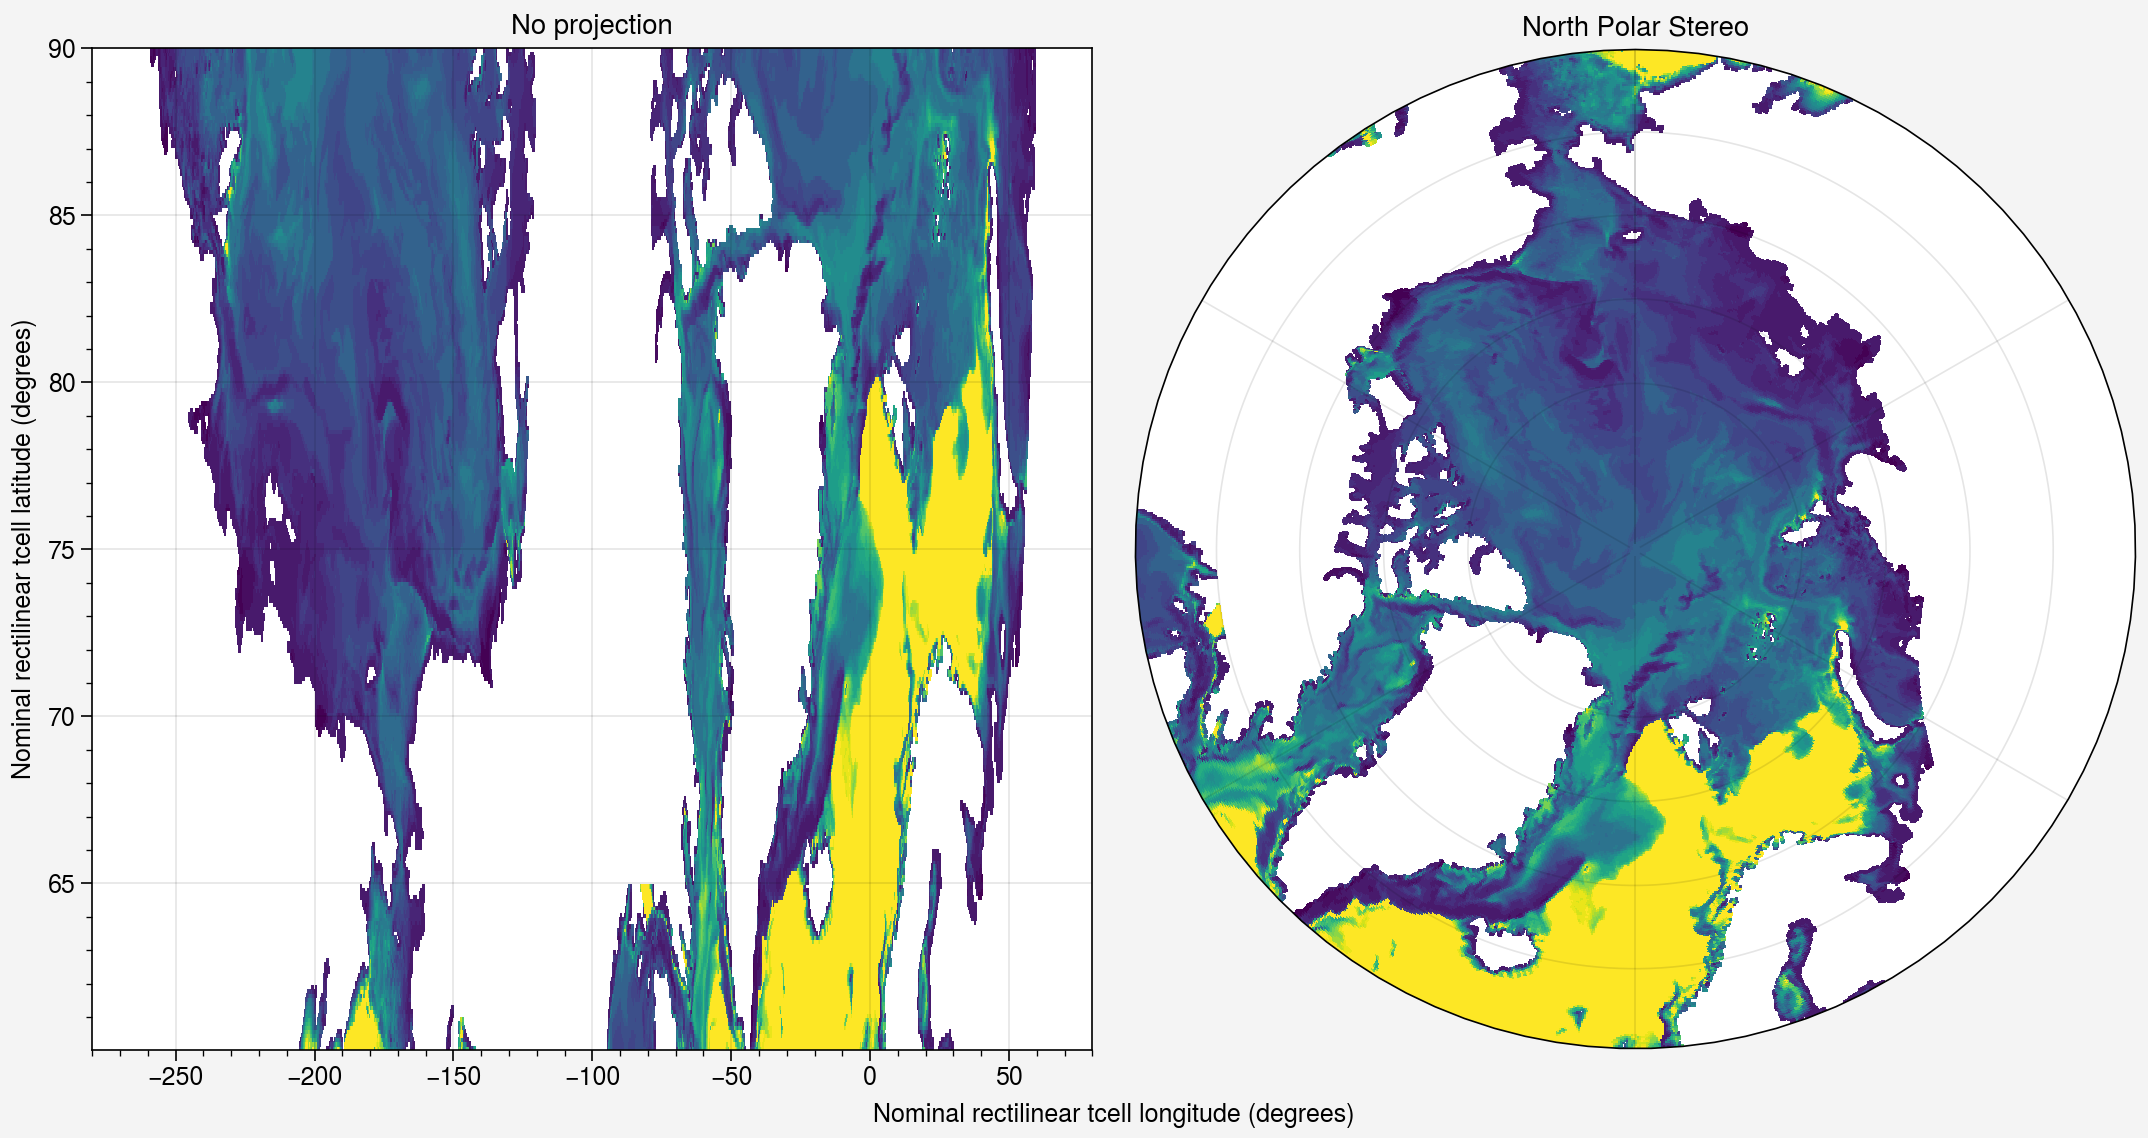

In [8]:
fig, ax = uplt.subplots(ncols=2, proj=(None,'nplaea'), axheight=5)
ax[0].pcolormesh(mask_month.xt_ocean, mask_month.yt_ocean, 
              mask_month.mld.isel(time=10), vmin=0, vmax=150, N=30, cmap='viridis')
ax[1].pcolormesh(ds_mesh.geolon_t.fillna(-9999), ds_mesh.geolat_t.fillna(-9999), 
              mask_month.mld.isel(time=10), vmin=0, vmax=150, N=30, cmap='viridis')
ax.format(land=False, boundinglat=60, title=('No projection', 'North Polar Stereo'))

## 4. Context map

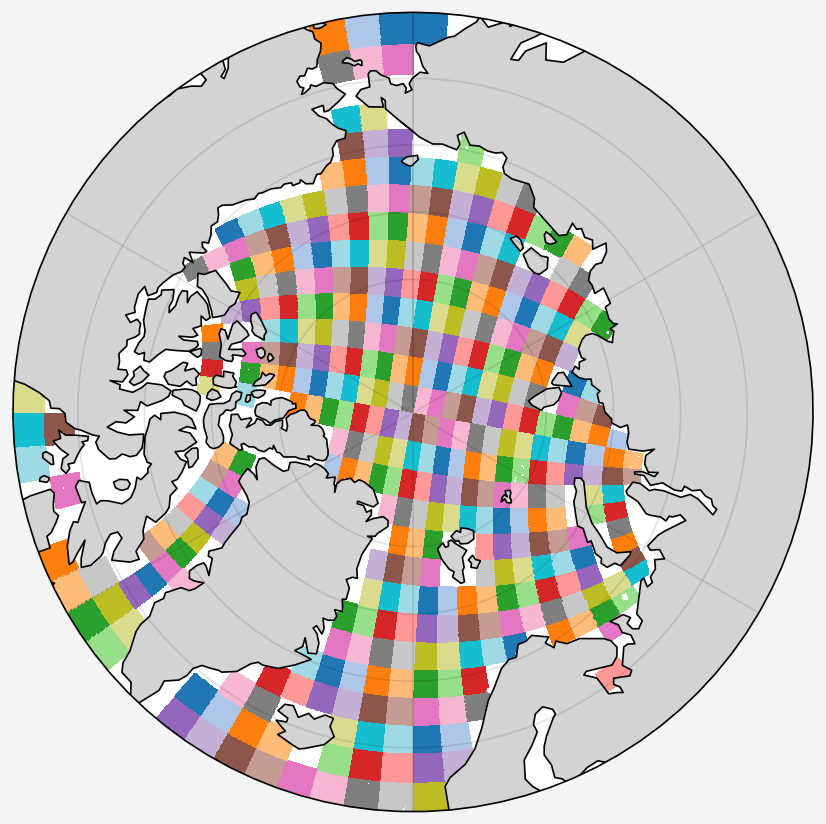

In [9]:
fig, ax = uplt.subplots(axwidth=4, proj='nplaea')
ax.pcolormesh(da_tiles.geolon_t.fillna(-9999), da_tiles.geolat_t.fillna(-9999), 
              da_tiles, cmap='tab20', N=1000)
ax.format(boundinglat=60, land=True, landcolor='lightgrey', coast=True,)

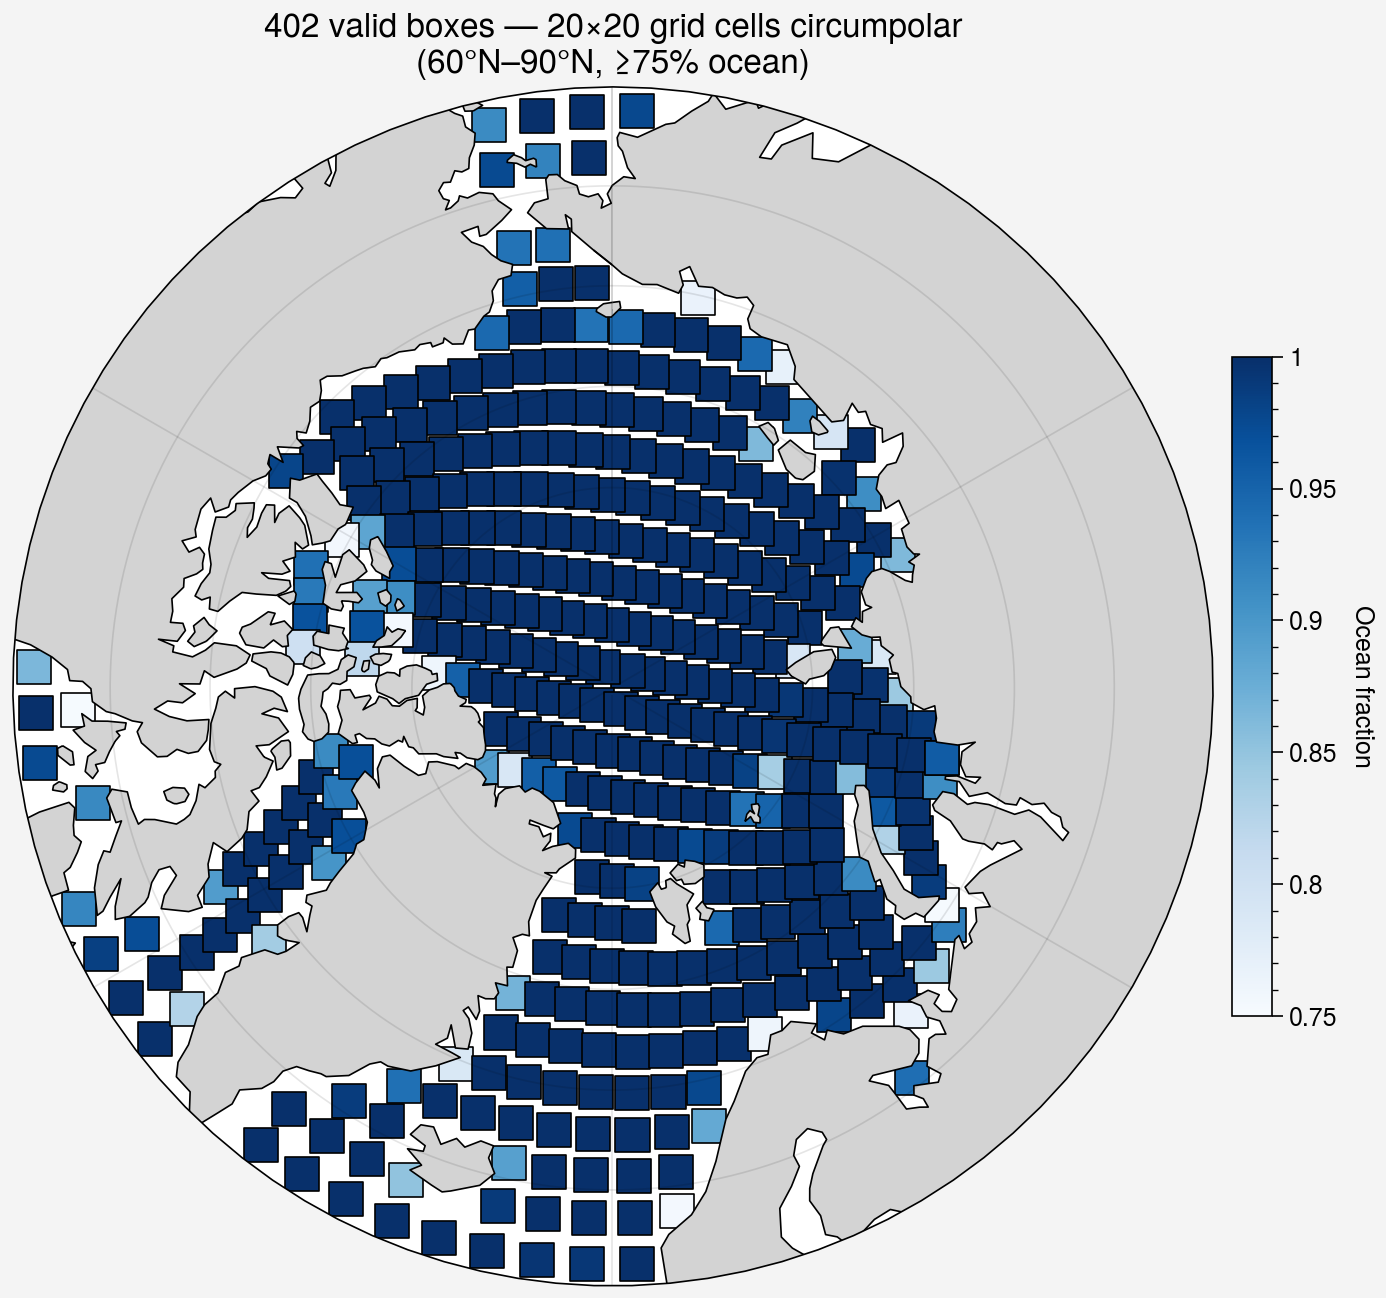

In [10]:
fig, ax = uplt.subplots(axwidth=6, proj='nplaea')
cmap_frac = uplt.Colormap('Blues')
norm_frac  = mcolors.Normalize(MIN_OCN_FRAC, 1.0)

lon_c, lat_c = [], []
color = []
for box in all_boxes:
    lon0  = box['lon_geo_min'] if box['lon_geo_min'] <= 180 else box['lon_geo_min'] - 360
    color.append(cmap_frac(norm_frac(box['ocean_frac'])))
    lon_c.append(box['lon_center'])
    lat_c.append(box['lat_center'])
    # ax.add_patch(Rectangle(
    #     (lon0, box['lat_min']), BOX_SIZE, BOX_SIZE,
    #     facecolor=color, edgecolor='k', linewidth=0.3,
    #     alpha=0.85, transform=ccrs.PlateCarree(), zorder=4,
    # ))
ax.scatter(lon_c, lat_c, c=color, s=150, m='s', edgecolor='k')
sm = plt.cm.ScalarMappable(cmap=cmap_frac, norm=norm_frac)
sm.set_array([])
ax.colorbar(sm, label='Ocean fraction', shrink=0.55, pad=0.05)
ax.set_title(
    f'{len(all_boxes)} valid boxes — {BOX_SIZE}×{BOX_SIZE} grid cells circumpolar\n'
    f'({abs(LAT_MIN):.0f}°N–{abs(LAT_MAX):.0f}°N, ≥{int(MIN_OCN_FRAC*100)}% ocean)',
    fontsize=12,
)
ax.format(boundinglat=60, land=True, landcolor='lightgrey', coast=True,)

## 5. Running as a PBS batch job on Gadi

This notebook processes ~150 boxes over 10 years of daily data.  The largest cost is
the pre-compute step (section 8); scale the walltime from how long the equivalent
step took in notebook 02 for 6 boxes.

Submit as a headless PBS job so it survives terminal disconnection:

```bash
cat > run_circumpolar.pbs << 'EOF'
#!/bin/bash
#PBS -N polar_mhw_circ
#PBS -q normal
#PBS -l walltime=8:00:00        # adjust based on NB02 runtime × ~25
#PBS -l mem=96GB
#PBS -l ncpus=8
#PBS -l storage=gdata/av17+gdata/hh5
#PBS -j oe

module use /g/data/hh5/public/modules
module load conda/analysis3

cd $PBS_O_WORKDIR
jupyter nbconvert --to notebook --execute --inplace \\
    --ExecutePreprocessor.timeout=28800 \\
    notebooks/03_polar_mhw_circumpolar.ipynb
EOF
qsub run_circumpolar.pbs
```

**Before submitting:** run with `TEST_MODE = True` (section 1) to verify the
Drake Passage boxes match notebook 02 results, then flip back to `False`.

## 6. Load circumpolar data (lazy)

In [52]:
mlt_files = base.glob('ocean_daily_mlt_output???.nc')

ds_wide = xr.open_mfdataset(
    mlt_files,
    decode_times=True, chunks=chunks2D,
    combine='nested', concat_dim='time',
    data_vars=['temp_in_mld', 'mld'],
    parallel=True, decode_timedelta=False,
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
# Also assign x and y coordinates
ds_wide = ds_wide.assign_coords({'x':('xt_ocean',np.arange(0,len(ds_wide.xt_ocean))),
                                 'y':('yt_ocean',np.arange(0,len(ds_wide.yt_ocean)))})

temp_wide = ds_wide['temp_in_mld'] / 1035
print(f"MLT loaded (lazy): {dict(ds_wide.dims)}")

MLT loaded (lazy): {'time': 3652, 'yt_ocean': 280, 'xt_ocean': 1440}


/tmp/ipykernel_3045398/2684356405.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"MLT loaded (lazy): {dict(ds_wide.dims)}")


In [59]:
budget_files = base.glob('../mlt_budget_online_stavg/mlt_budget_stavg_daily_online_output???.nc')

vars_raw = [
    'mlt_tendency', 'advection', 'vert_mixing',
    'entrainment', 'surface_flux', 'sw_pen', 'residual',
]

budget_wide = xr.open_mfdataset(
    budget_files,
    decode_times=True, chunks=chunks2D,
    combine='nested', concat_dim='time',
    parallel=True, decode_timedelta=False,
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))[vars_raw]
# Also assign x and y coordinates
budget_wide = budget_wide.assign_coords({'x':('xt_ocean',np.arange(0,len(budget_wide.xt_ocean))),
                                         'y':('yt_ocean',np.arange(0,len(budget_wide.yt_ocean)))})
budget_wide['surf_to_ML'] = budget_wide['surface_flux'] + budget_wide['sw_pen']

clim_wide   = xr.open_dataset(
    base.joinpath('../om2_025_MLT_clim.nc')
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
clim_wide = clim_wide.assign_coords({'x':('xt_ocean',np.arange(0,len(clim_wide.xt_ocean))),
                                     'y':('yt_ocean',np.arange(0,len(clim_wide.yt_ocean)))})

thresh_wide = xr.open_dataset(
    base.joinpath('../om2_025_MLT_thresh.nc')
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
thresh_wide = thresh_wide.assign_coords({'x':('xt_ocean',np.arange(0,len(thresh_wide.xt_ocean))),
                                         'y':('yt_ocean',np.arange(0,len(thresh_wide.yt_ocean)))})

budget_clim_wide = xr.open_dataset(
    base.joinpath('../mlt_budget_online_stavg/'
           'mlt_budget_stavg_daily_online_output336-365_monthly_mean.ncea.nc')
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
budget_clim_wide = budget_clim_wide.assign_coords({'x':('xt_ocean',np.arange(0,len(budget_clim_wide.xt_ocean))),
                                                   'y':('yt_ocean',np.arange(0,len(budget_clim_wide.yt_ocean)))})
budget_clim_wide['surf_to_ML'] = (
    budget_clim_wide['surface_flux'] + budget_clim_wide['sw_pen']
)

print(f"Budget loaded (lazy): {dict(budget_wide.dims)}")
print("Climatology files opened.")

Budget loaded (lazy): {'time': 3652, 'yt_ocean': 280, 'xt_ocean': 1440}
Climatology files opened.


/tmp/ipykernel_3045398/629692943.py:41: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Budget loaded (lazy): {dict(budget_wide.dims)}")


## 7. Helper functions

In [63]:
def _weights(da):
    return np.cos(np.deg2rad(da['yt_ocean']))


def _box_mean(da, box):
    sub = _box_slice(da, box)
    return sub.weighted(_weights(sub)).mean(('xt_ocean', 'yt_ocean'))


def detect_mhw_events(temp_da, thresh_da, min_dur=5, max_gap=2):
    """Hobday et al. (2016) event detection. Returns list of dicts: t_start, t_peak, t_end."""
    t      = pd.to_datetime(temp_da.time.values)
    y_temp = temp_da.values
    y_thr  = thresh_da.values
    valid  = np.isfinite(y_temp) & np.isfinite(y_thr)

    if valid.sum() < min_dur:
        return []

    exceed = pd.Series((y_temp[valid] > y_thr[valid]).astype(int), index=t[valid])

    runs        = (exceed.diff(1).ne(0)).cumsum()
    run_lengths = exceed.groupby(runs).transform('size')
    short_false = (exceed == 0) & (run_lengths <= max_gap)
    merged      = exceed.copy()
    merged[short_false] = 1

    runs2     = (merged.diff(1).ne(0)).cumsum()
    lens2     = merged.groupby(runs2).transform('size')
    long_true = (merged == 1) & (lens2 >= min_dur)

    anom = pd.Series(y_temp[valid] - y_thr[valid], index=t[valid])
    arr, idx = long_true.to_numpy(), long_true.index.to_numpy()
    events, start_i = [], None
    for i in range(len(arr)):
        if arr[i] and start_i is None:
            start_i = i
        if start_i is not None and (i == len(arr) - 1 or not arr[i + 1]):
            seg    = anom.iloc[start_i:i + 1]
            t_peak = seg.idxmax()
            events.append({'t_start': idx[start_i], 't_peak': t_peak, 't_end': idx[i]})
            start_i = None
    return events


def get_season(timestamp):
    """Austral season from month of timestamp."""
    m = pd.Timestamp(timestamp).month
    if m in (12, 1, 2): return 'DJF'
    if m in (3, 4, 5):  return 'MAM'
    if m in (6, 7, 8):  return 'JJA'
    return 'SON'


def build_budget_clim_daily(budget_clim_box, budget_time):
    """Interpolate monthly budget climatology to daily and apply 31-day smoothing."""
    clim_by_month = (
        budget_clim_box.groupby('time.month').mean('time')
        .assign_coords(month=np.arange(1, 13))
    )
    dec         = clim_by_month.sel(month=12).expand_dims(month=[0])
    jan         = clim_by_month.sel(month=1).expand_dims(month=[13])
    clim_padded = xr.concat([dec, clim_by_month, jan], dim='month')
    clim_smooth = clim_padded.interp(month=np.linspace(1, 12, 365))

    doys = (budget_time.dt.dayofyear - 1) % 365
    clim_daily = xr.Dataset({
        name: clim_smooth[name].isel(month=doys).assign_coords(time=budget_time)
        for name in BUDGET_TERMS
    })
    return clim_daily.rolling(time=31, center=True, min_periods=1).mean()


print("Helper functions defined.")

Helper functions defined.


## 8. Pre-compute all box means — by latitude band

Data are loaded lazily for the full circumpolar strip.  Computing all ~150 boxes in a
single Dask graph can be slow to optimise; processing one latitude band at a time
(~72 boxes per band) keeps each graph tractable.  Results are accumulated in plain
dicts so the loop in section 9 can access them by `box_id`.

In [65]:
# Organise valid boxes into y (close to latitude) bands
y_band_centers = np.unique([box['y_center'] for box in all_boxes])

y_bands = {}
for y_c in y_band_centers:
    y_bands[y_c] = [
        (bid, box) for bid, box in zip(box_ids, all_boxes)
        if abs(box['y_center'] - y_c) < 0.01
    ]

# Per-band checkpointing: a lat band's results are pickled to disk once computed,
# so a crash (e.g. a transient Gadi I/O error) only loses the in-progress band —
# re-running the cell resumes from the last completed band instead of starting over.
CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def checkpoint_path(y_c):
    return f'{CHECKPOINT_DIR}/y_band_{y_c:.1f}.pkl'


mlt_all    = {}
clim_all   = {}
thresh_all = {}
budget_all = {}
bclim_all  = {}

for y_c, band in y_bands.items():
    if not band:
        continue

    ckpt = checkpoint_path(y_c)
    if os.path.exists(ckpt):
        print(f"\n── Y band {y_c:d}  ({len(band)} boxes) — loaded from checkpoint ──")
        with open(ckpt, 'rb') as fh:
            saved = pickle.load(fh)
        mlt_all.update(saved['mlt'])
        clim_all.update(saved['clim'])
        thresh_all.update(saved['thresh'])
        budget_all.update(saved['budget'])
        bclim_all.update(saved['bclim'])
        continue

    print(f"\n── Y band {y_c:d}  ({len(band)} boxes) ──────────────")

    # MLT, climatology, threshold
    mlt_lazy    = {bid: _box_mean(temp_wide,        box) for bid, box in band}
    clim_lazy   = {bid: _box_mean(clim_wide.temp,   box) for bid, box in band}
    thresh_lazy = {bid: _box_mean(thresh_wide.temp, box) for bid, box in band}
    print("  Computing MLT / clim / threshold ...")
    mlt_band    = dict(xr.Dataset(mlt_lazy).compute())
    clim_band   = dict(xr.Dataset(clim_lazy).compute())
    thresh_band = dict(xr.Dataset(thresh_lazy).compute())

    # Budget time series
    budget_lazy = {}
    for bid, box in band:
        sub = _box_slice(budget_wide, box)
        w   = _weights(sub)
        for term, raw in TERM_MAP.items():
            budget_lazy[f"{bid}__{term}"] = (
                sub[raw].weighted(w).mean(('yt_ocean', 'xt_ocean')) * SEC_PER_DAY
            )
    print("  Computing budget time series ...")
    budget_band = dict(xr.Dataset(budget_lazy).compute())

    # Budget climatology (monthly means — cheap)
    bclim_lazy = {}
    for bid, box in band:
        bc = _box_slice(budget_clim_wide, box)
        w  = _weights(bc)
        for term, raw in TERM_MAP.items():
            bclim_lazy[f"{bid}__{term}"] = (
                bc[raw].weighted(w).mean(('yt_ocean', 'xt_ocean')) * SEC_PER_DAY
            )
    print("  Computing budget climatology ...")
    bclim_band = dict(xr.Dataset(bclim_lazy).compute())

    with open(ckpt, 'wb') as fh:
        pickle.dump({
            'mlt': mlt_band, 'clim': clim_band, 'thresh': thresh_band,
            'budget': budget_band, 'bclim': bclim_band,
        }, fh)

    mlt_all.update(mlt_band)
    clim_all.update(clim_band)
    thresh_all.update(thresh_band)
    budget_all.update(budget_band)
    bclim_all.update(bclim_band)

print("\nAll bands done — data in memory.")


── Y band 10.0°  (20 boxes) ──────────────
  Computing MLT / clim / threshold ...


/cofast/brichaud/envs_mamba/Poly_env/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 13.45 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Computing budget time series ...
  Computing budget climatology ...

── Y band 30.0°  (17 boxes) ──────────────
  Computing MLT / clim / threshold ...


/cofast/brichaud/envs_mamba/Poly_env/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 11.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Computing budget time series ...
  Computing budget climatology ...

── Y band 50.0°  (9 boxes) ──────────────
  Computing MLT / clim / threshold ...
  Computing budget time series ...
  Computing budget climatology ...

── Y band 70.0°  (12 boxes) ──────────────
  Computing MLT / clim / threshold ...
  Computing budget time series ...
  Computing budget climatology ...

── Y band 90.0°  (16 boxes) ──────────────
  Computing MLT / clim / threshold ...


...

  Computing budget time series ...
  Computing budget climatology ...

── Y band 234.0°  (1 boxes) ──────────────
  Computing MLT / clim / threshold ...
  Computing budget time series ...
  Computing budget climatology ...

── Y band 250.0°  (42 boxes) ──────────────
  Computing MLT / clim / threshold ...


/cofast/brichaud/envs_mamba/Poly_env/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 28.55 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Computing budget time series ...
  Computing budget climatology ...

── Y band 270.0°  (50 boxes) ──────────────
  Computing MLT / clim / threshold ...


/cofast/brichaud/envs_mamba/Poly_env/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 33.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Computing budget time series ...
  Computing budget climatology ...

All bands done — data in memory.


## 9. Loop over boxes — MHW detection and budget decomposition

In [77]:
all_events = {}
all_df     = {}

for k, (bid, box) in enumerate(zip(box_ids, all_boxes)):
    if k % 20 == 0:
        print(f"[{k:3d}/{len(all_boxes)}] "
              f"x={box['x_center']:6.1f}  y={box['y_center']:.1f}")

    temp_vals   = mlt_all[bid]
    ## TEMPORARY
    temp_vals = temp_vals.sortby('time')
    ##
    clim_mean   = clim_all[bid]
    thresh_mean = thresh_all[bid]

    doy_all        = temp_vals.time.dt.dayofyear.clip(max=365)
    clim_on_time   = clim_mean.sel(dayofyear=doy_all).assign_coords(time=temp_vals.time)
    thresh_on_time = thresh_mean.sel(dayofyear=doy_all).assign_coords(time=temp_vals.time)

    events = detect_mhw_events(temp_vals, thresh_on_time, MIN_DUR, MAX_GAP)
    all_events[bid] = events

    if not events:
        all_df[bid] = pd.DataFrame()
        continue

    budget_series = xr.Dataset(
        {term: budget_all[f"{bid}__{term}"] for term in BUDGET_TERMS}
    )
    ## TEMPORARY
    budget_series = budget_series.sortby('time')
    ##
    bc_box = xr.Dataset(
        {term: bclim_all[f"{bid}__{term}"] for term in BUDGET_TERMS}
    )
    clim_daily  = build_budget_clim_daily(bc_box, budget_series.time)
    anom_series = xr.Dataset(
        {name: budget_series[name] - clim_daily[name] for name in BUDGET_TERMS}
    )

    rows = []
    for ev in events:
        t_s, t_p, t_e = ev['t_start'], ev['t_peak'], ev['t_end']
        season = get_season(t_p)
        for name in BUDGET_TERMS:
            rows.append({
                't_start': t_s, 't_peak': t_p, 't_end': t_e,
                'season' : season, 'term': name,
                'onset'  : float(anom_series[name].sel(time=slice(t_s, t_p)).mean()),
                'decline': float(anom_series[name].sel(time=slice(t_p, t_e)).mean()),
            })
    all_df[bid] = pd.DataFrame(rows)

total_events = sum(len(v) for v in all_events.values())
print(f"\nDone. {total_events} events across {len(all_boxes)} boxes.")

[  0/402] x= 390.0  y=10.0
[ 20/402] x= 410.0  y=30.0
[ 40/402] x=1070.0  y=50.0
[ 60/402] x= 430.0  y=90.0
[ 80/402] x= 410.0  y=110.0
[100/402] x= 250.0  y=130.0
[120/402] x=1070.0  y=130.0
[140/402] x= 370.0  y=150.0
[160/402] x=1150.0  y=150.0
[180/402] x= 390.0  y=170.0
[200/402] x=1250.0  y=170.0
[220/402] x= 510.0  y=190.0
[240/402] x= 270.0  y=210.0
[260/402] x=1090.0  y=210.0
[280/402] x= 330.0  y=230.0
[300/402] x=1130.0  y=230.0
[320/402] x= 350.0  y=250.0
[340/402] x=1130.0  y=250.0
[360/402] x= 270.0  y=270.0
[380/402] x= 950.0  y=270.0
[400/402] x=1350.0  y=270.0

Done. 5587 events across 402 boxes.


## 10. Save results to NetCDF

In [144]:
x_centers = np.array([(j + 0.5) * BOX_SIZE for j in range(n_x)]).astype('int')
x_centers

array([  10,   30,   50,   70,   90,  110,  130,  150,  170,  190,  210,
        230,  250,  270,  290,  310,  330,  350,  370,  390,  410,  430,
        450,  470,  490,  510,  530,  550,  570,  590,  610,  630,  650,
        670,  690,  710,  730,  750,  770,  790,  810,  830,  850,  870,
        890,  910,  930,  950,  970,  990, 1010, 1030, 1050, 1070, 1090,
       1110, 1130, 1150, 1170, 1190, 1210, 1230, 1250, 1270, 1290, 1310,
       1330, 1350, 1370, 1390, 1410, 1430])

In [162]:
y_centers = np.array([(i + 0.5) * BOX_SIZE for i in range(n_y)]).astype('int')
x_centers = np.array([(j + 0.5) * BOX_SIZE for j in range(n_x)]).astype('int')

def box_to_idx(box):
    y_c0 = 0.0 + BOX_SIZE / 2
    x_c0 = BOX_SIZE / 2
    li  = int(round((box['y_center'] - y_c0) / BOX_SIZE))
    loi = int(round((box['x_center'] - x_c0) / BOX_SIZE))
    return li, loi

onset_grids   = {t: np.full((n_y, n_x), np.nan) for t in BUDGET_TERMS}
decline_grids = {t: np.full((n_y, n_x), np.nan) for t in BUDGET_TERMS}
n_events_grid = np.full((n_y, n_x), np.nan)
ocn_frac_grid = np.full((n_y, n_x), np.nan)
lat_grid = np.full((n_y, n_x), -9999)
lon_grid = np.full((n_y, n_x), -9999)

for bid, box in zip(box_ids, all_boxes):
    li, loi = box_to_idx(box)
    ocn_frac_grid[li, loi] = box['ocean_frac']
    lat_grid[li, loi]      = box['lat_center']
    lon_grid[li, loi]      = box['lon_center']
    n_events_grid[li, loi] = len(all_events[bid])
    df = all_df[bid]
    if df.empty:
        continue
    for term in BUDGET_TERMS:
        sub = df[df.term == term]
        onset_grids[term][li, loi]   = sub['onset'].mean()
        decline_grids[term][li, loi] = sub['decline'].mean()

data_vars = {
    'n_events'  : (['y', 'x'], n_events_grid,
                   {'long_name': 'Number of MHW events detected'}),
    'ocean_frac': (['y', 'x'], ocn_frac_grid,
                   {'long_name': 'Ocean cell fraction (from January mask)'}),
}
for term in BUDGET_TERMS:
    key = term.lower().replace(' ', '_')
    data_vars[f'onset_{key}']   = (
        ['y', 'x'], onset_grids[term],
        {'long_name': f'Onset composite — {term}', 'units': 'degC day-1'}
    )
    data_vars[f'decline_{key}'] = (
        ['y', 'x'], decline_grids[term],
        {'long_name': f'Decline composite — {term}', 'units': 'degC day-1'}
    )

ds_out = xr.Dataset(
    data_vars,
    coords={
        'y': ('y', y_centers, {'units': 'y_gridcell', 'long_name': 'Box centre y'}),
        'x': ('x', x_centers, {'units': 'x_gridcell', 'long_name': 'Box centre x'}),
        'lat': (['y','x'], lat_grid, {'units': 'degrees_north', 'long_name': 'Box centre lat'}),
        'lon': (['y','x'], lon_grid, {'units': 'degrees_east',  'long_name': 'Box centre lon'}),
    },
    attrs={
        'description' : 'Arctic Circumpolar MHW mixed-layer heat budget composites',
        'model'       : 'ACCESS-OM2 0.25° IAF cycle 6',
        'outputs'     : f'{START_OUTPUT}–{END_OUTPUT} (2010–2019)',
        'box_size_deg': BOX_SIZE,
        'min_ocn_frac': MIN_OCN_FRAC,
        'mhw_min_dur' : MIN_DUR,
        'mhw_max_gap' : MAX_GAP,
    }
)

out_path = f'{OUTPUT_DIR}/04_Arctic_circumpolar_mhw_budget.nc'
# ds_out.to_netcdf(out_path)
# print(f"Saved → {out_path}")
ds_out

<xarray.Dataset> Size: 114kB
Dimensions:                  (y: 14, x: 72)
Coordinates:
  * y                        (y) int64 112B 10 30 50 70 90 ... 210 230 250 270
  * x                        (x) int64 576B 10 30 50 70 ... 1370 1390 1410 1430
    lat                      (y, x) int64 8kB -9999 -9999 -9999 ... -9999 -9999
    lon                      (y, x) int64 8kB -9999 -9999 -9999 ... -9999 -9999
Data variables:
    n_events                 (y, x) float64 8kB nan nan nan nan ... nan nan nan
    ocean_frac               (y, x) float64 8kB nan nan nan nan ... nan nan nan
    onset_mlt_tendency       (y, x) float64 8kB nan nan nan nan ... nan nan nan
    decline_mlt_tendency     (y, x) float64 8kB nan nan nan nan ... nan nan nan
    onset_surface_flux       (y, x) float64 8kB nan nan nan nan ... nan nan nan
    decline_surface_flux     (y, x) float64 8kB nan nan nan nan ... nan nan nan
    onset_advection          (y, x) float64 8kB nan nan nan nan ... nan nan nan
    decline_advection        (y, x) float64 8kB nan nan nan nan ... nan nan nan
    onset_vertical_mixing    (y, x) float64 8kB nan nan nan nan ... nan nan nan
    decline_vertical_mixing  (y, x) float64 8kB nan nan nan nan ... nan nan nan
    onset_entrainment        (y, x) float64 8kB nan nan nan nan ... nan nan nan
    decline_entrainment      (y, x) float64 8kB nan nan nan nan ... nan nan nan
Attributes:
    description:   Arctic Circumpolar MHW mixed-layer heat budget composites
    model:         ACCESS-OM2 0.25° IAF cycle 6
    outputs:       357–366 (2010–2019)
    box_size_deg:  20
    min_ocn_frac:  0.75
    mhw_min_dur:   5
    mhw_max_gap:   2

## 11. Summary maps

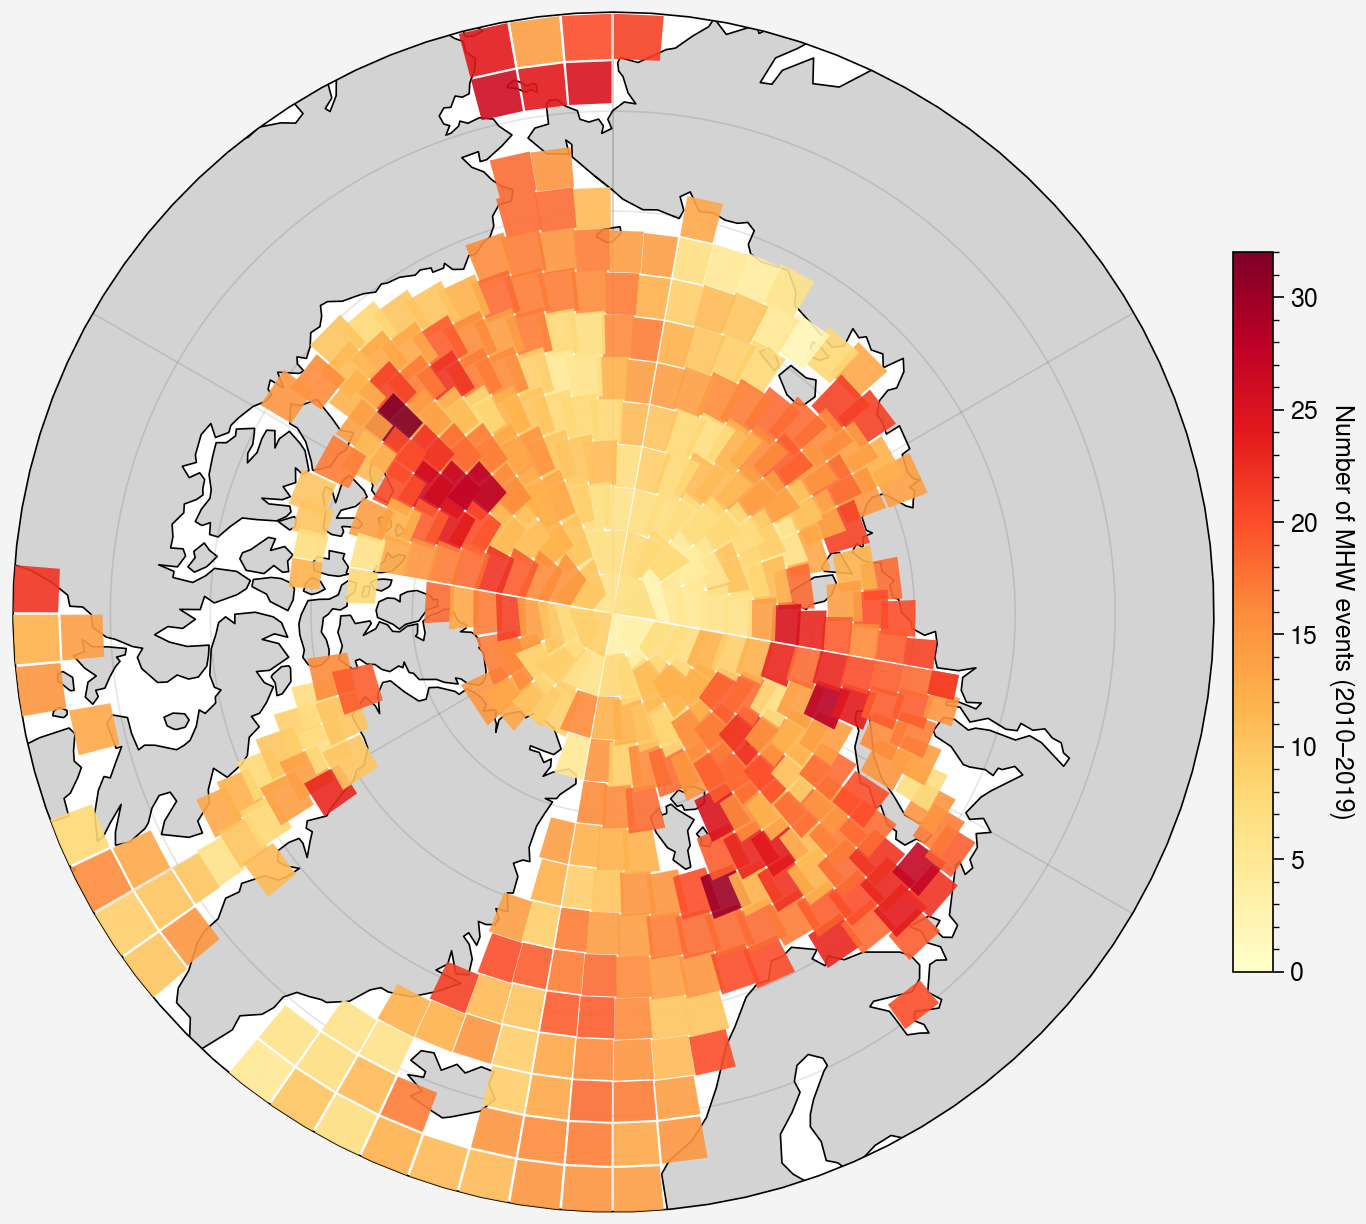

In [241]:
# ── 11a. Event count map ──────────────────────────────────────────────────────
fig, axs = uplt.subplots(axwidth=6, proj='nplaea')
vmax_ev = np.nanmax(n_events_grid)
norm_ev = mcolors.Normalize(0, vmax_ev)
cmap_ev = plt.cm.YlOrRd

for box in all_boxes:
    li, loi = box_to_idx(box)
    n = n_events_grid[li, loi]
    if np.isnan(n):
        continue
    lon0  = box['lon_min_ds'] if box['lon_min_ds'] <= 180 else box['lon_min_ds'] - 360
    lon1  = box['lon_max_ds'] if box['lon_max_ds'] <= 180 else box['lon_max_ds'] - 360
    color = cmap_ev(norm_ev(n))
    axs.add_patch(Rectangle(
        (lon0, box['lat_min']), lon1 - lon0, box['lat_max'] - box['lat_min'],
        facecolor=color, edgecolor='none',
        alpha=0.9, transform=ccrs.PlateCarree(), zorder=4,
    ))
# axs.scatter(ds_out.lon, ds_out.lat, c=ds_out.n_events, s=150, m='o', cmap=cmap_ev, vmax=40)#, N=40)
sm = plt.cm.ScalarMappable(cmap=cmap_ev, norm=norm_ev)
sm.set_array([])
plt.colorbar(sm, ax=axs, label='Number of MHW events (2010–2019)',
             shrink=0.6, pad=0.05)
# ax.set_title(
#     f'MHW event count — circumpolar {BOX_SIZE}×{BOX_SIZE} boxes\n'
#     f'({total_events} events total, 2010–2019)',
#     fontsize=12,
# )
axs.format(land=True, landcolor='lightgrey', coast=True, boundinglat=60)
# plt.tight_layout()

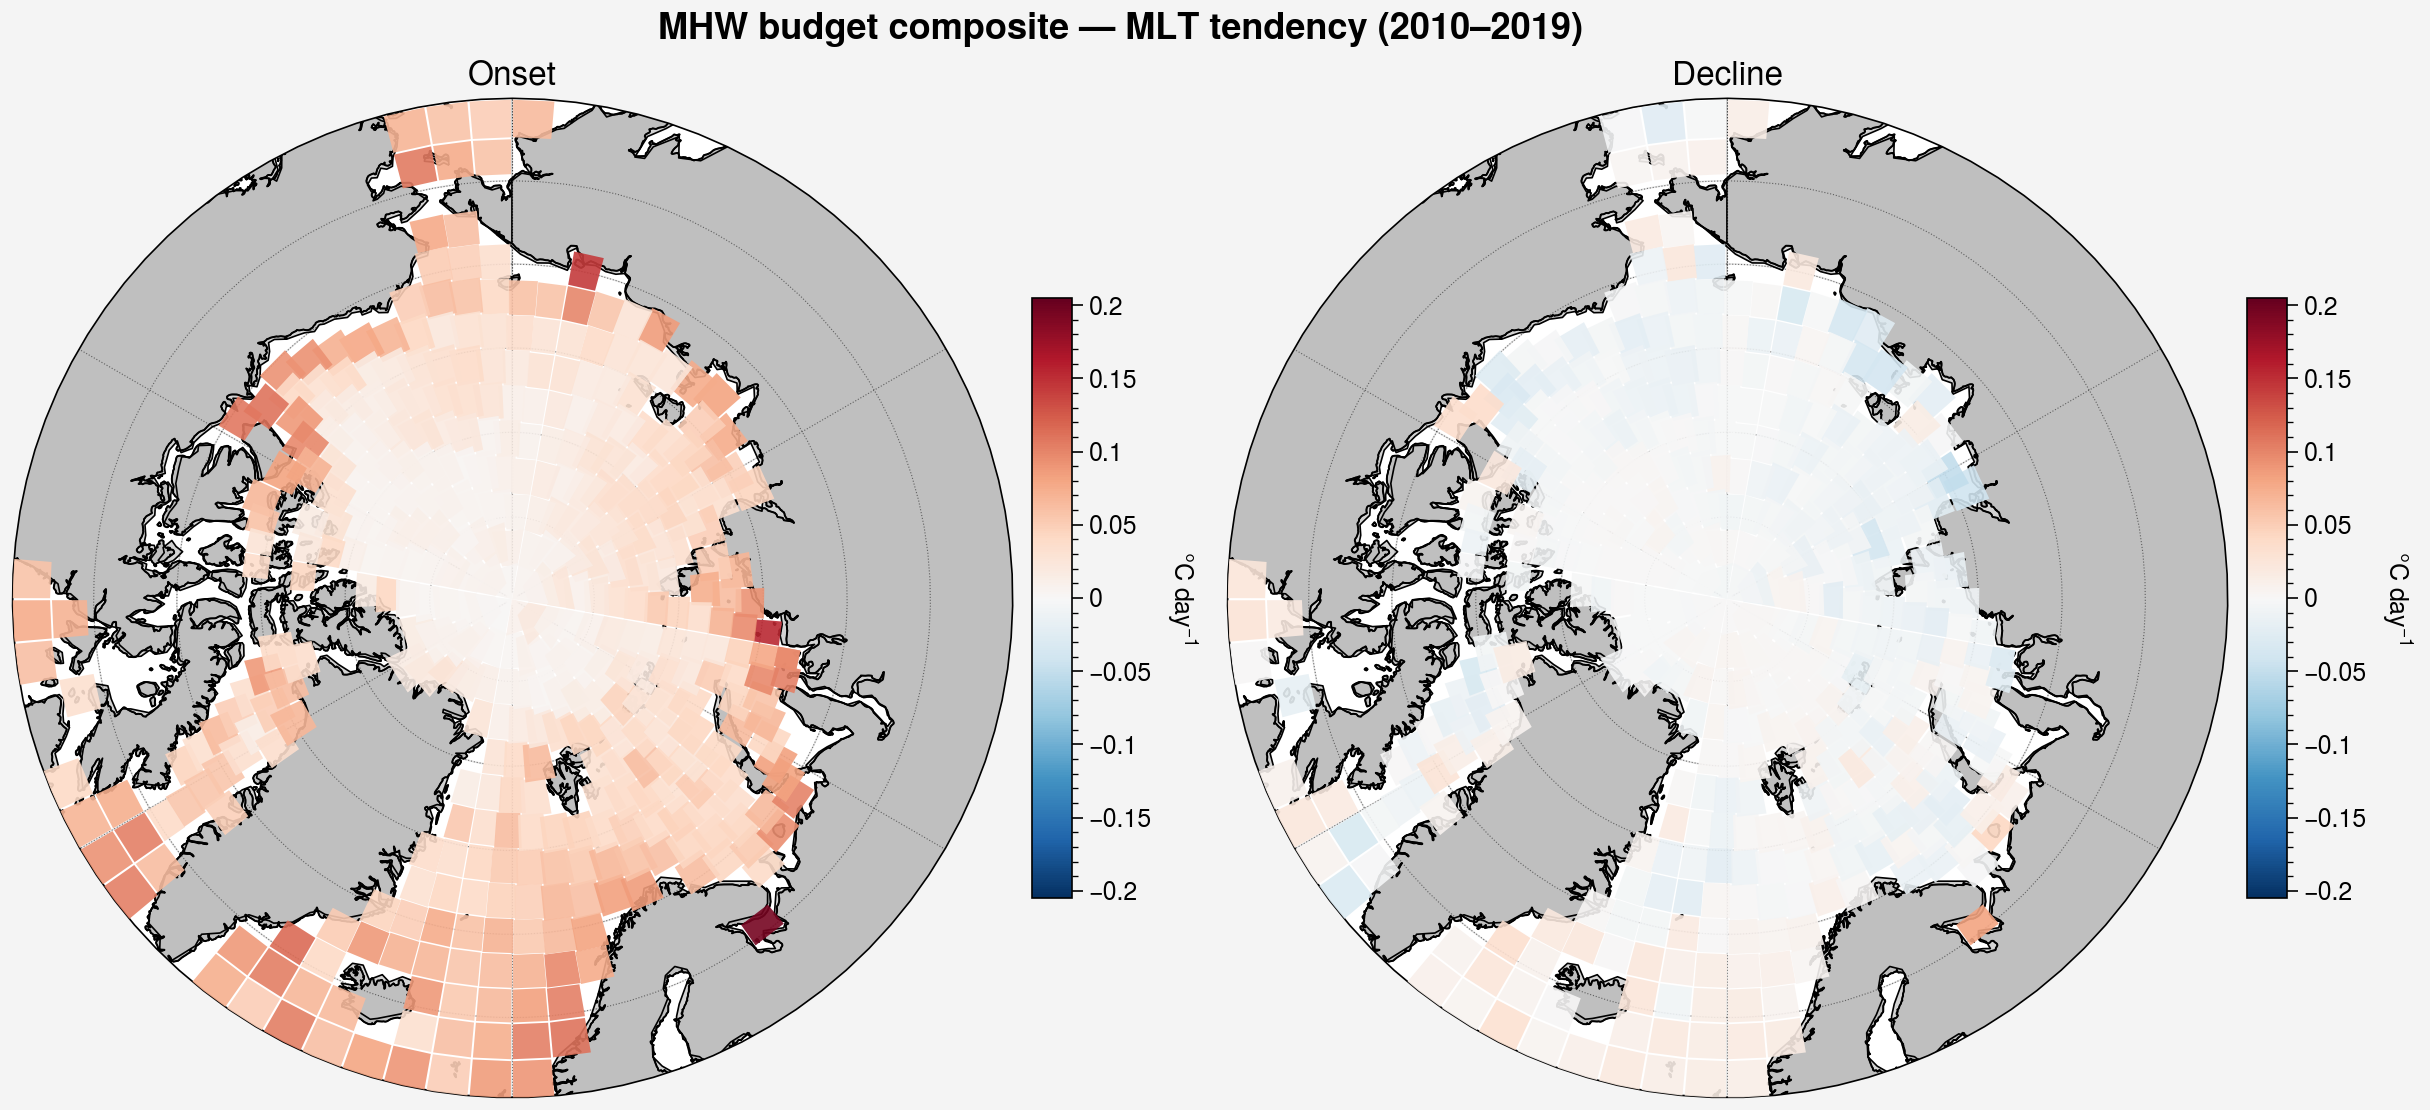

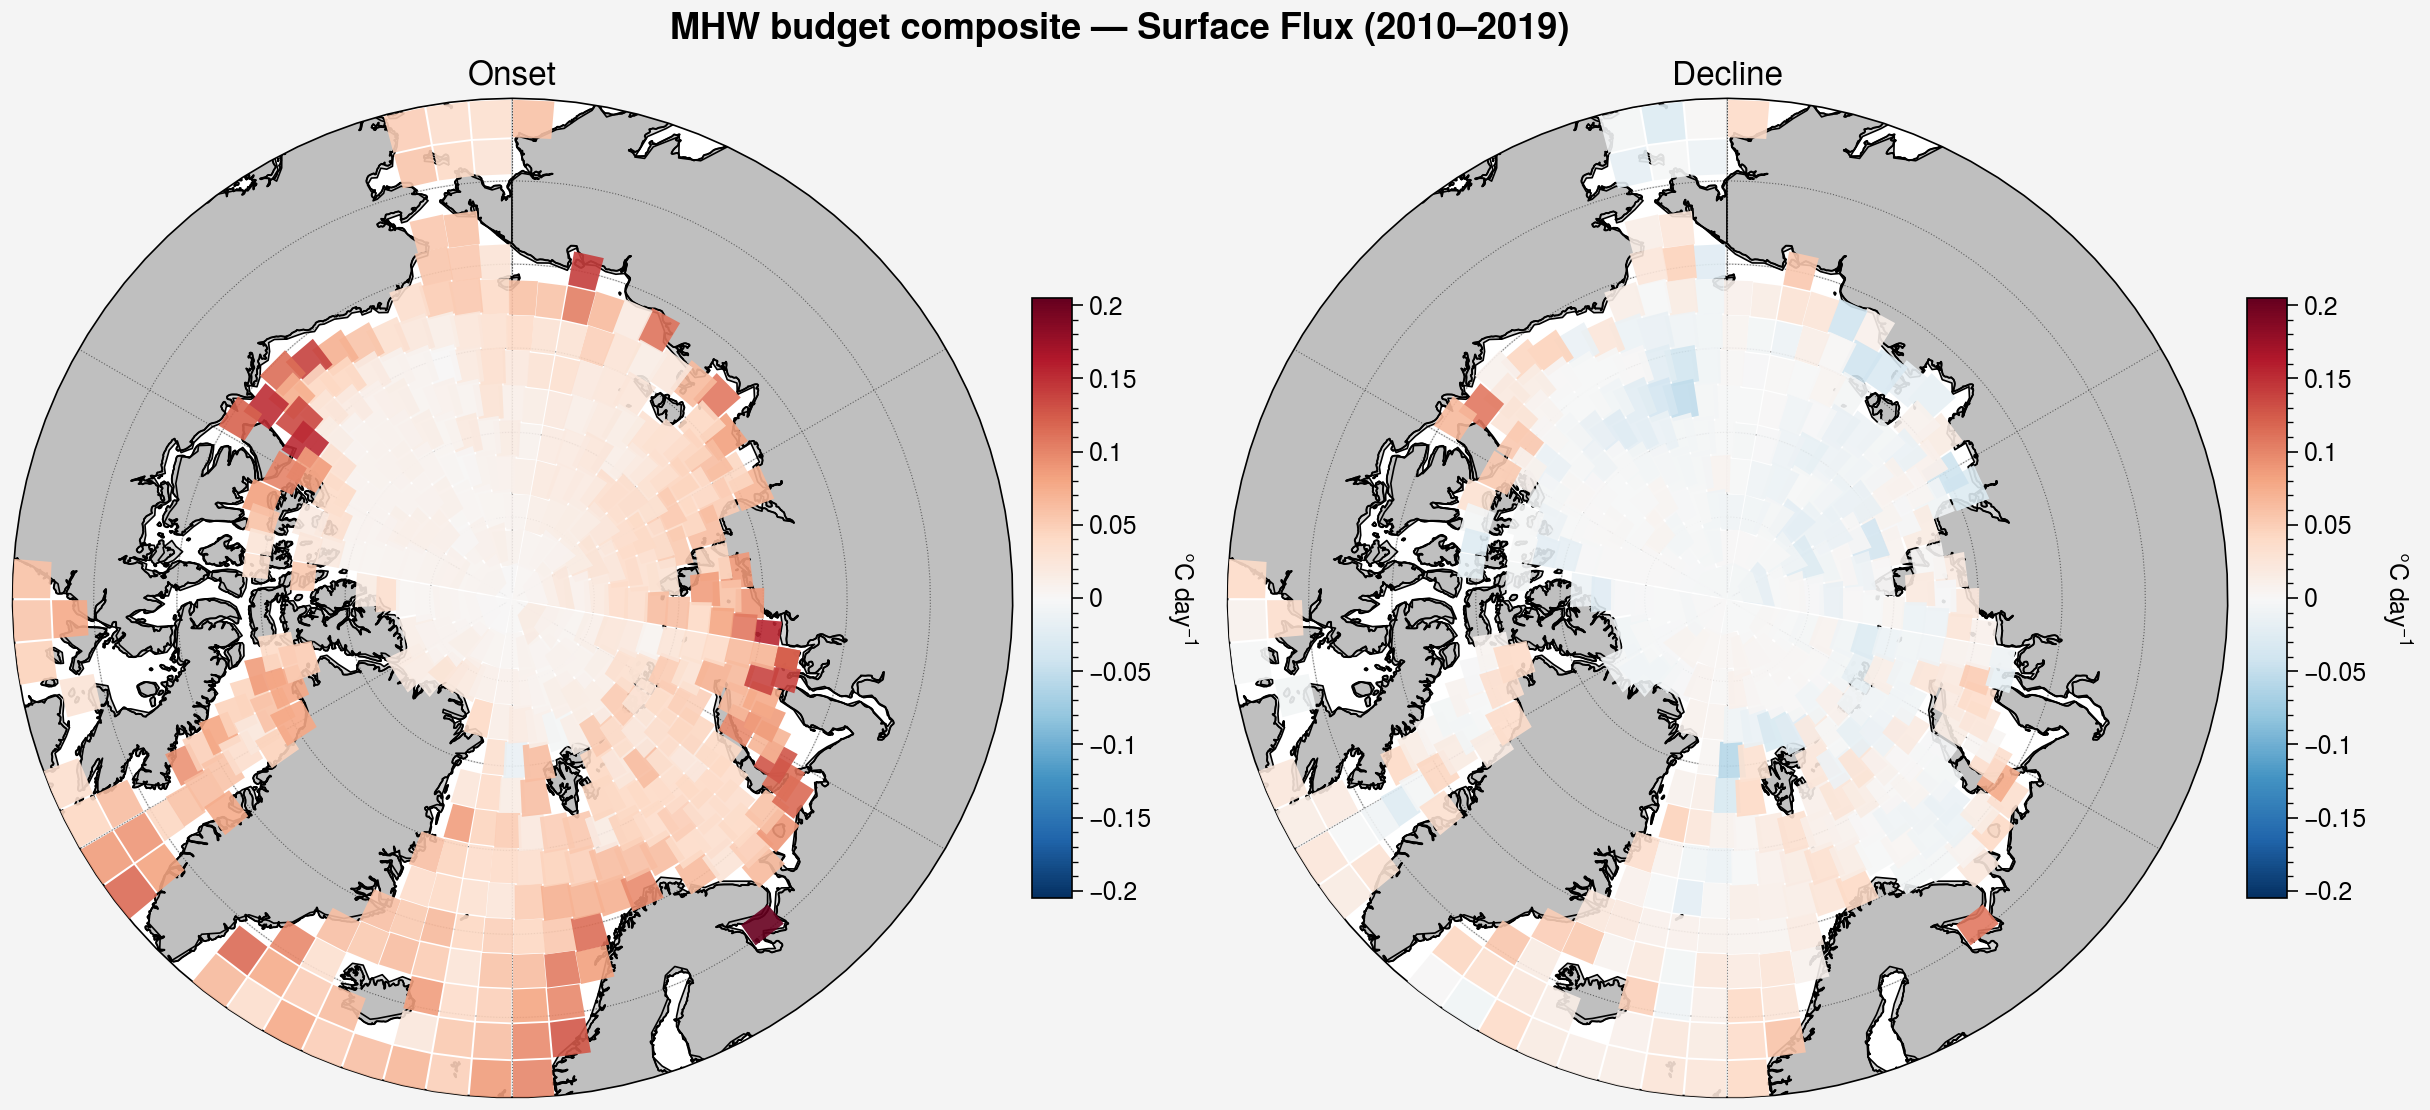

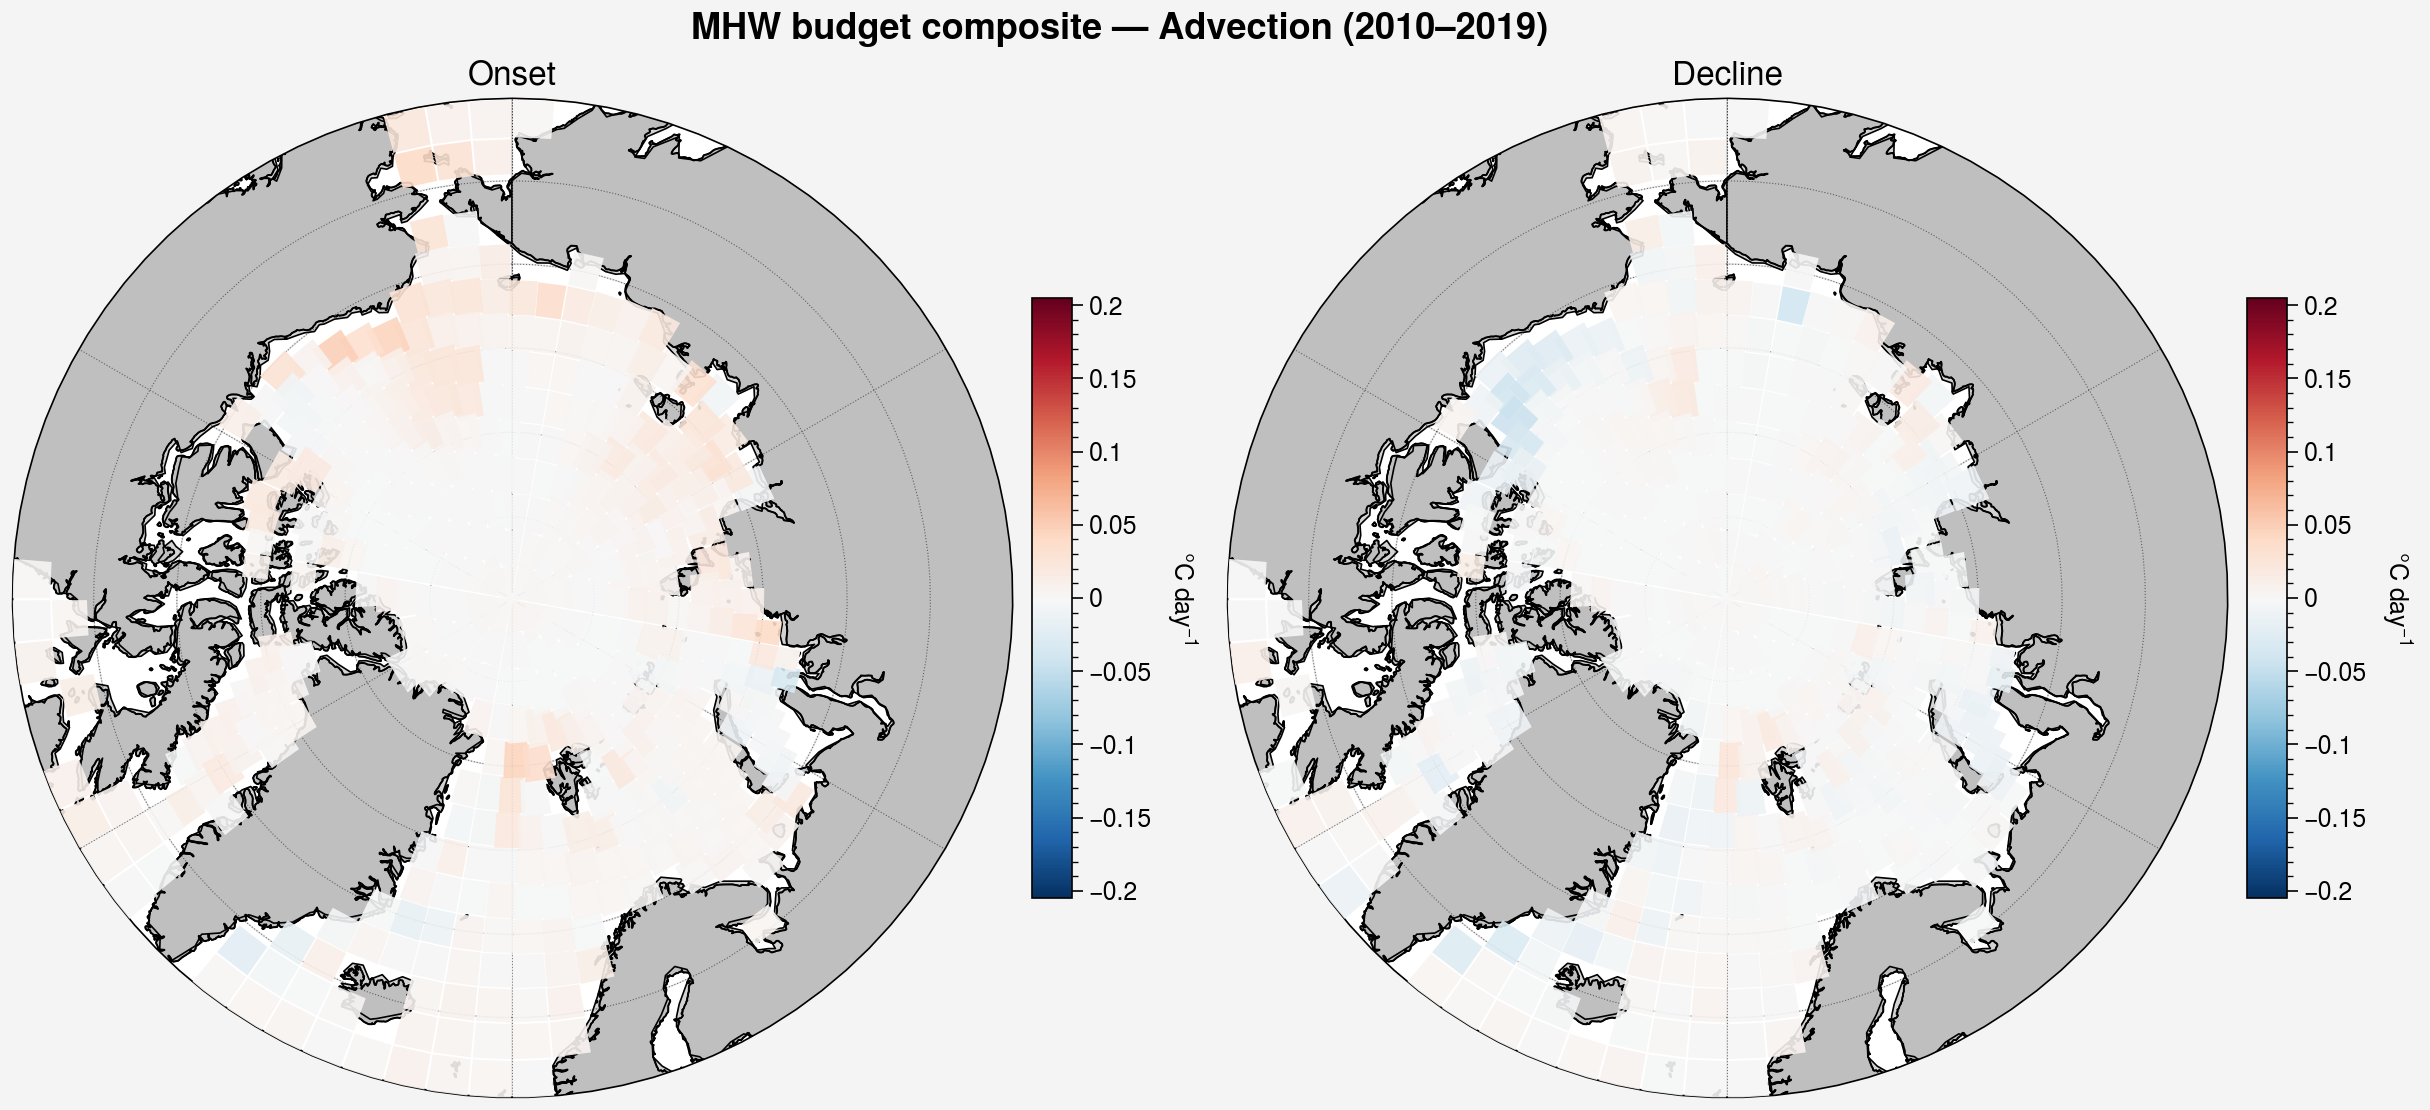

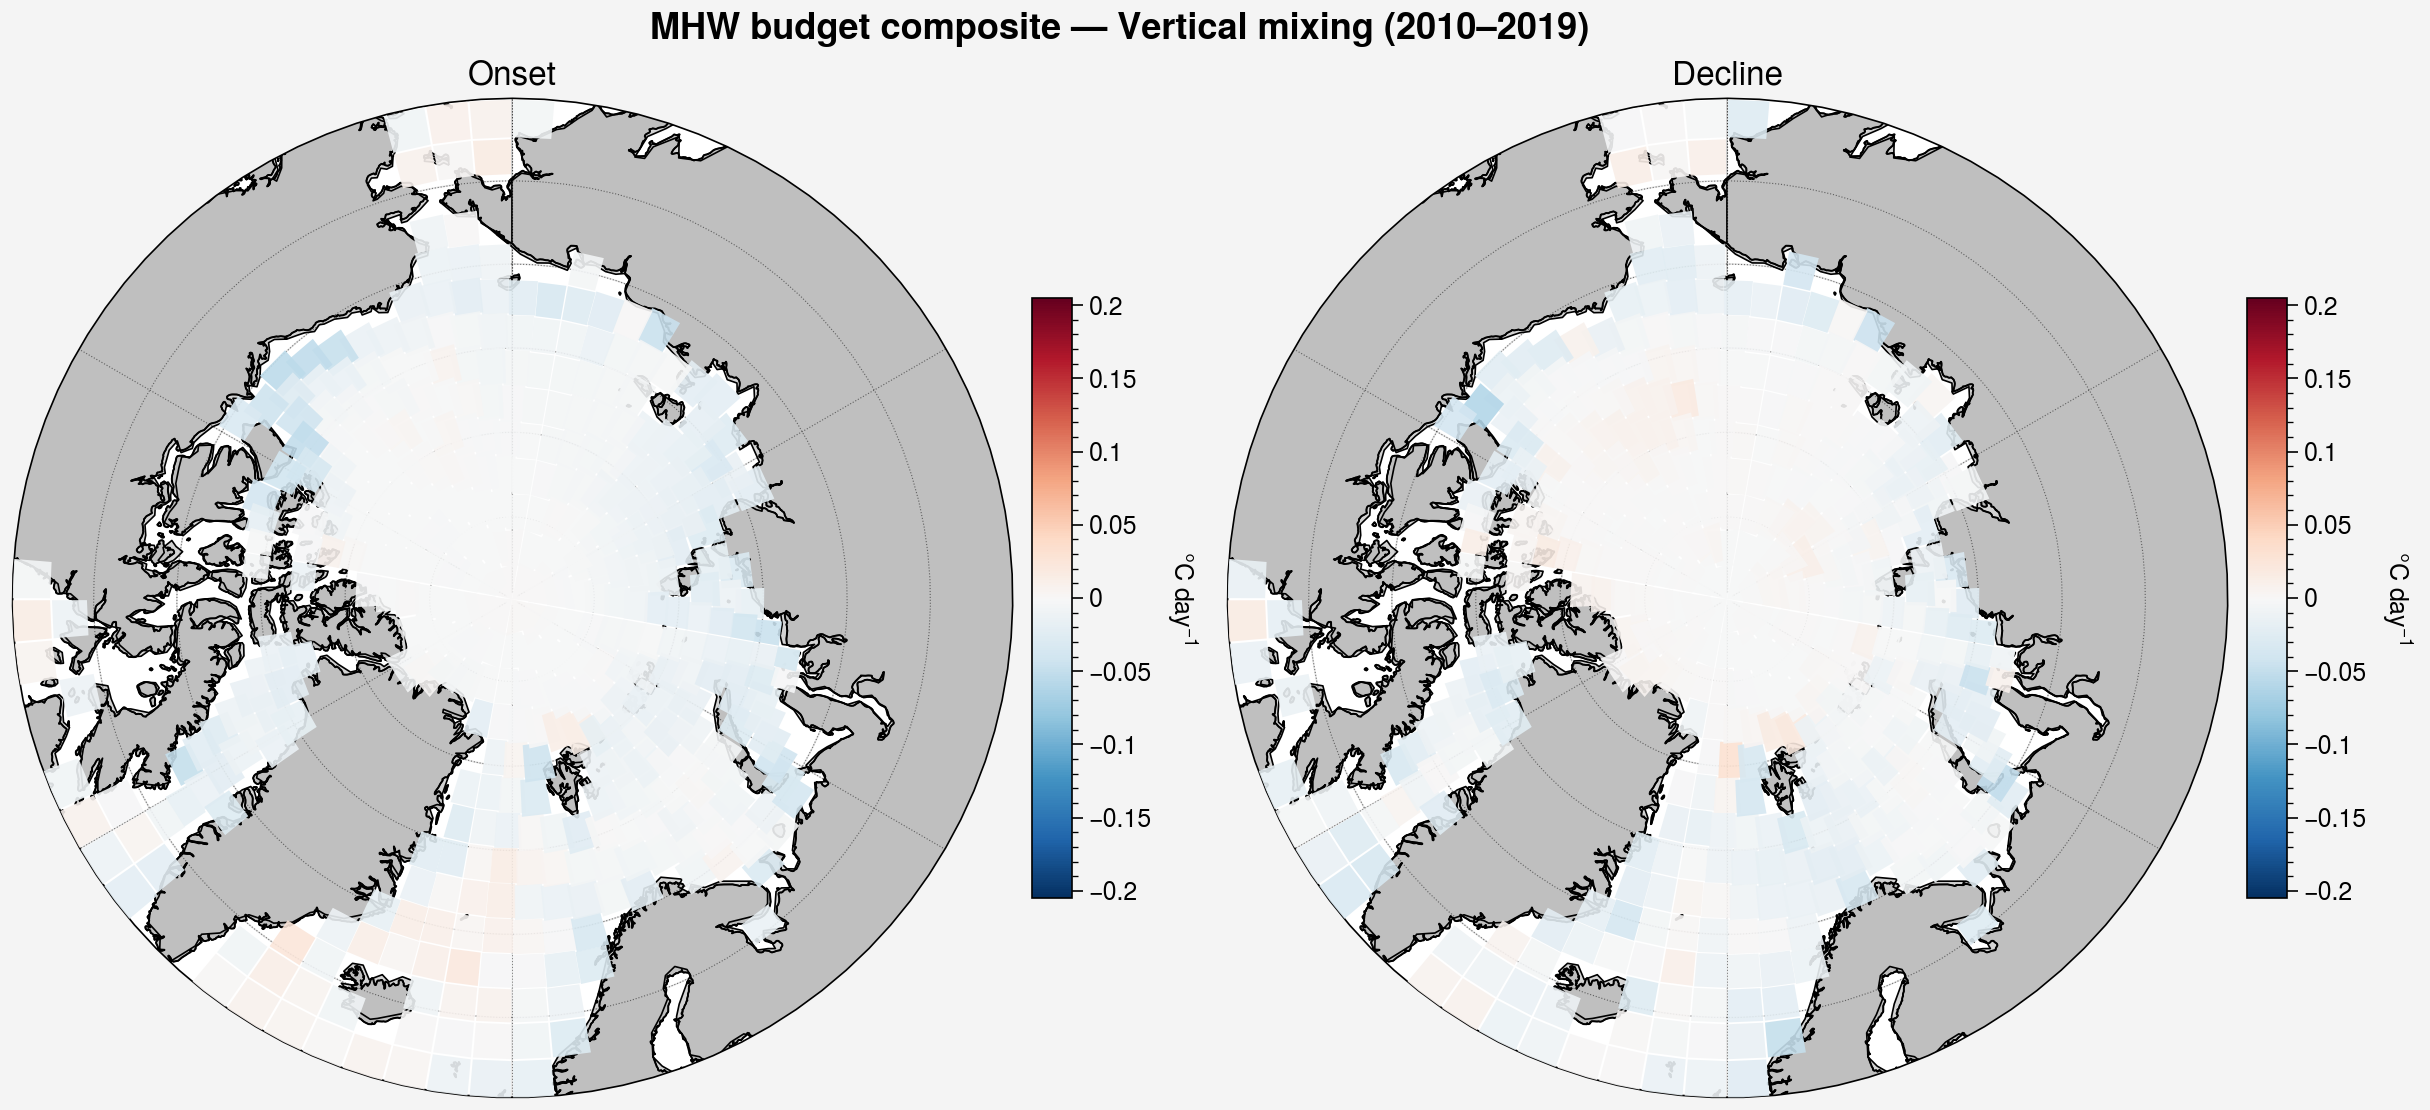

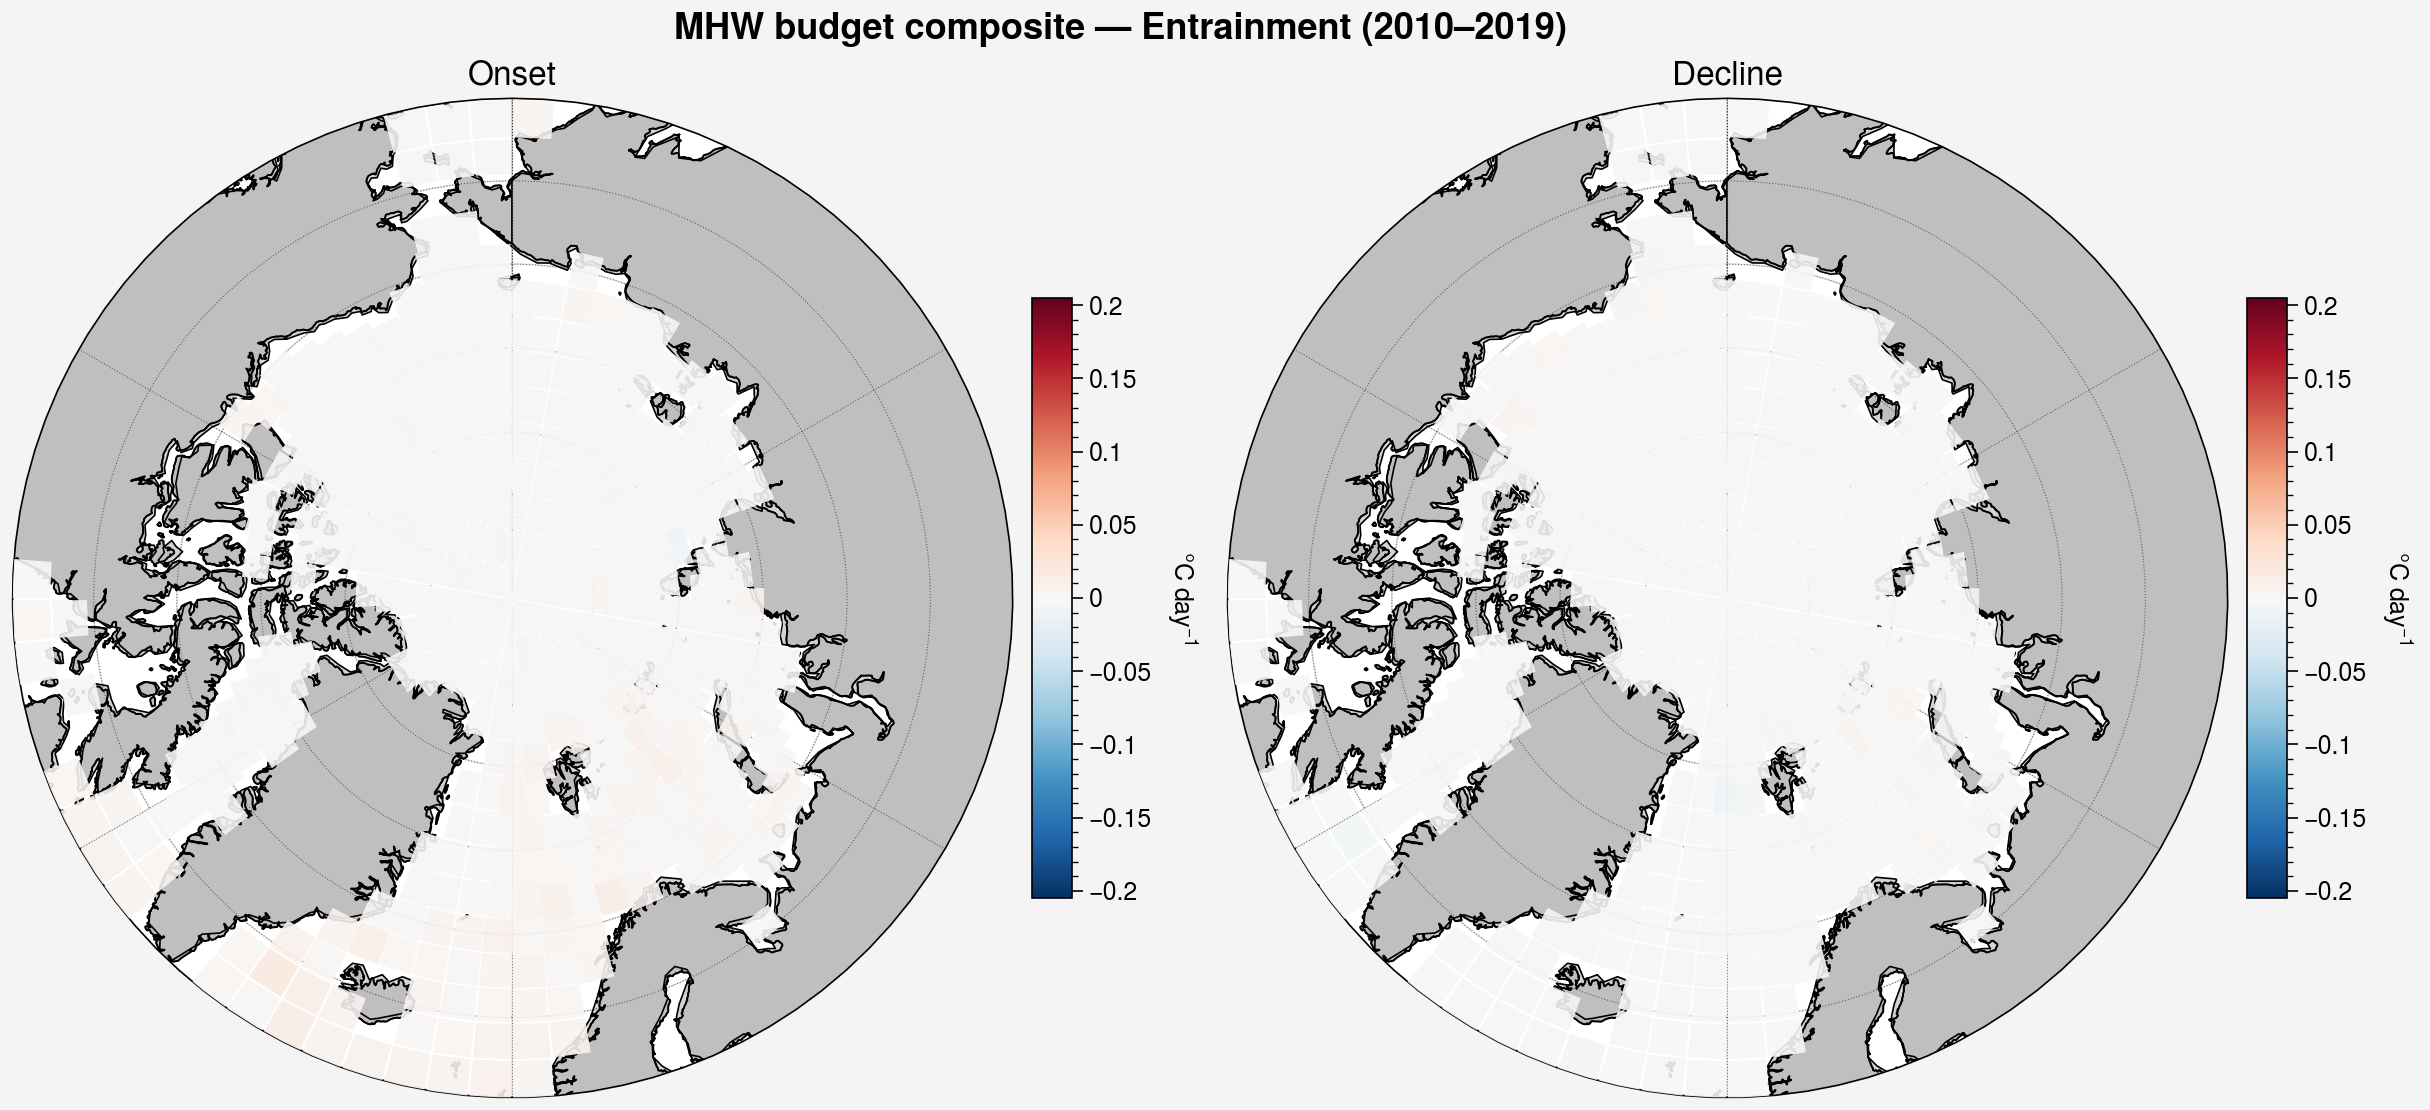

In [246]:
# ── 11b. Onset and decline composite maps — one figure per budget term ─────────
# Colour scale is shared across every term/phase panel (not recomputed per term) so
# magnitudes are directly comparable term to term, not just within a single term's
# own onset vs decline.
vmax_global = np.nanmax([np.nanmax(np.abs(onset_grids[term])) for term in BUDGET_TERMS]
                        + [np.nanmax(np.abs(decline_grids[term])) for term in BUDGET_TERMS])
norm_t = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax_global, vmax=vmax_global)

for term in BUDGET_TERMS:
    mat_on = onset_grids[term]
    mat_de = decline_grids[term]
    if np.all(np.isnan(mat_on)) and np.all(np.isnan(mat_de)):
        continue

    fig, axs = uplt.subplots(ncols=2, axwidth=5, proj='nplaea')

    for ax, mat, phase in zip(axs, [mat_on, mat_de], ['Onset', 'Decline']):

        for box in all_boxes:
            li, loi = box_to_idx(box)
            v = mat[li, loi]
            if np.isnan(v):
                continue
            color = plt.cm.RdBu_r(norm_t(v))
            lon0  = box['lon_min_ds'] if box['lon_min_ds'] <= 180 else box['lon_min_ds'] - 360
            lon1  = box['lon_max_ds'] if box['lon_max_ds'] <= 180 else box['lon_max_ds'] - 360
            ax.add_patch(Rectangle(
                (lon0, box['lat_min']), lon1 - lon0, box['lat_max'] - box['lat_min'],
                facecolor=color, edgecolor='none',
                alpha=0.9, transform=ccrs.PlateCarree(), zorder=4,
            ))

        sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_t)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='°C day$^{-1}$', shrink=0.6, pad=0.05)
        ax.set_title(phase, fontsize=12)
    
    axs.format(land=True, landcolor='lightgrey', coast=True, boundinglat=60)
    fig.suptitle(f'MHW budget composite — {term} (2010–2019)', fontsize=13)
    # plt.tight_layout()

## 12. Dominant drivers and event-to-event variability

The MLT tendency term is excluded from driver identification below — it is the response
variable on the LHS of the budget equation (the sum of the other terms), not itself a physical
driver of onset/decline. The remaining 4 terms (Surface Flux, Advection, Vertical mixing,
Entrainment) are the candidate "drivers".

For each box, three related but distinct questions about which of these terms drives onset and decline:

- **Dominant term** — which driver term has the largest mean |anomaly| across all events in the
  box (the same information as the Section 11b composite maps, reduced to "which term wins").
- **Driver consistency** — for each *individual* event, which driver term has the largest
  |anomaly|? This map shows the fraction of events in a box where that per-event top term
  matches the box's most common top term. **1.0** = the same term dominates every event.
  **0.25** (= 1/4 driver terms) = the "winning" term is essentially random from event to event —
  no consistent driver.
- **Driver magnitude variability (CV)** — even when the same term dominates every event, does it
  dominate by a similar amount each time, or does its size vary a lot? This is the coefficient of
  variation (std / |mean|) of the box's dominant term across events. Low = stable driver strength;
  high = same driver, but wildly different strength event to event.

Boxes with fewer than 2 events, or where every driver term is NaN for a given event (e.g. the box
was fully sea-ice-covered through that event's onset or decline window), are left blank.

In [15]:
# Exclude the tendency term (LHS of the budget equation) from driver identification —
# it is the quantity being decomposed, not one of the physical processes explaining it.
DRIVER_TERMS = [t for t in BUDGET_TERMS if t != 'MLT tendency']

n_terms   = len(DRIVER_TERMS)
term_idx  = {t: i for i, t in enumerate(DRIVER_TERMS)}
EVENT_KEY = ['t_start', 't_peak', 't_end']


def _dominant_term(vals_by_term):
    """Term with the largest |value|; None if all NaN."""
    valid = {t: v for t, v in vals_by_term.items() if not np.isnan(v)}
    return max(valid, key=lambda t: abs(valid[t])) if valid else None


def _event_dominant_terms(df, phase):
    """Per event, the driver term with the largest |phase| value.

    Skips events where every driver term is NaN for this phase (e.g. the box was fully
    sea-ice-covered through the onset/decline window), rather than letting idxmax raise.
    """
    df = df[df.term.isin(DRIVER_TERMS)]
    dom_terms = []
    for _, group in df.groupby(EVENT_KEY):
        vals = group.set_index('term')[phase].abs()
        if vals.notna().any():
            dom_terms.append(vals.idxmax())
    return dom_terms


dom_term_onset_grid      = np.full((n_lat, n_lon), np.nan)
dom_term_decline_grid    = np.full((n_lat, n_lon), np.nan)
consistency_onset_grid   = np.full((n_lat, n_lon), np.nan)
consistency_decline_grid = np.full((n_lat, n_lon), np.nan)
cv_onset_grid            = np.full((n_lat, n_lon), np.nan)
cv_decline_grid          = np.full((n_lat, n_lon), np.nan)

for bid, box in zip(box_ids, valid_boxes):
    li, loi = box_to_idx(box)

    dom_on = _dominant_term({t: onset_grids[t][li, loi]   for t in DRIVER_TERMS})
    dom_de = _dominant_term({t: decline_grids[t][li, loi] for t in DRIVER_TERMS})
    if dom_on is not None:
        dom_term_onset_grid[li, loi] = term_idx[dom_on]
    if dom_de is not None:
        dom_term_decline_grid[li, loi] = term_idx[dom_de]

    if len(all_events[bid]) < 2:
        continue
    df = all_df[bid]

    for phase, cons_grid, cv_grid, dom_grid in (
        ('onset',   consistency_onset_grid,   cv_onset_grid,   dom_term_onset_grid),
        ('decline', consistency_decline_grid, cv_decline_grid, dom_term_decline_grid),
    ):
        dom_terms_per_event = _event_dominant_terms(df, phase)
        if not dom_terms_per_event:
            continue
        cons_grid[li, loi] = pd.Series(dom_terms_per_event).value_counts(normalize=True).iloc[0]

        dom_idx = dom_grid[li, loi]
        if not np.isnan(dom_idx):
            vals = df.loc[df.term == DRIVER_TERMS[int(dom_idx)], phase]
            if vals.mean() != 0:
                cv_grid[li, loi] = vals.std() / abs(vals.mean())

print("Driver dominance / consistency / CV grids computed (tendency excluded).")

Driver dominance / consistency / CV grids computed (tendency excluded).


In [ ]:
cmap_dom = mcolors.ListedColormap(plt.cm.tab10.colors[:n_terms])
norm_dom = mcolors.BoundaryNorm(np.arange(-0.5, n_terms, 1), cmap_dom.N)


def _new_polar_ax(fig, nrows, ncols, index):
    ax = fig.add_subplot(nrows, ncols, index, projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
    ax.coastlines(linewidth=0.7, zorder=3)
    ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)
    return ax


def _draw_boxes(ax, grid, cmap, norm):
    for box in valid_boxes:
        li, loi = box_to_idx(box)
        v = grid[li, loi]
        if np.isnan(v):
            continue
        lon0 = box['lon_geo_min'] if box['lon_geo_min'] <= 180 else box['lon_geo_min'] - 360
        ax.add_patch(Rectangle(
            (lon0, box['lat_min']), BOX_DEG, BOX_DEG,
            facecolor=cmap(norm(v)), edgecolor='none',
            alpha=0.9, transform=ccrs.PlateCarree(), zorder=4,
        ))


fig = plt.figure(figsize=(15, 7))
ax1 = _new_polar_ax(fig, 1, 2, 1)
ax2 = _new_polar_ax(fig, 1, 2, 2)
_draw_boxes(ax1, dom_term_onset_grid, cmap_dom, norm_dom)
_draw_boxes(ax2, dom_term_decline_grid, cmap_dom, norm_dom)
ax1.set_title('Onset', fontsize=12)
ax2.set_title('Decline', fontsize=12)

handles = [Rectangle((0, 0), 1, 1, facecolor=cmap_dom(i)) for i in range(n_terms)]
fig.legend(handles, DRIVER_TERMS, loc='lower center', ncol=n_terms, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Dominant driver term — largest mean |anomaly| across events (tendency excluded)',
             fontsize=13, y=1.02)
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12),
                         subplot_kw={'projection': ccrs.SouthPolarStereo()})

cmap_cons = plt.cm.viridis
norm_cons = mcolors.Normalize(0.0, 1.0)

cv_vmax = np.nanmax([cv_onset_grid, cv_decline_grid])
cmap_cv = plt.cm.magma_r
norm_cv = mcolors.Normalize(0.0, cv_vmax)

for ax in axes.flat:
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
    ax.coastlines(linewidth=0.7, zorder=3)
    ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

_draw_boxes(axes[0, 0], consistency_onset_grid,   cmap_cons, norm_cons)
_draw_boxes(axes[0, 1], consistency_decline_grid, cmap_cons, norm_cons)
_draw_boxes(axes[1, 0], cv_onset_grid,   cmap_cv, norm_cv)
_draw_boxes(axes[1, 1], cv_decline_grid, cmap_cv, norm_cv)

axes[0, 0].set_title('Onset — driver consistency', fontsize=11)
axes[0, 1].set_title('Decline — driver consistency', fontsize=11)
axes[1, 0].set_title('Onset — driver magnitude CV', fontsize=11)
axes[1, 1].set_title('Decline — driver magnitude CV', fontsize=11)

plt.colorbar(plt.cm.ScalarMappable(cmap=cmap_cons, norm=norm_cons),
             ax=axes[0, :], label='Fraction of events with same top term', shrink=0.7, pad=0.05)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap_cv, norm=norm_cv),
             ax=axes[1, :], label='CV of dominant term (std / |mean|)', shrink=0.7, pad=0.05)

fig.suptitle('Driver consistency and magnitude variability across events\n'
             '(boxes with <2 events left blank)', fontsize=13)

## 13. Event duration and intensity

For each box, summary statistics of MHW event characteristics across 2010–2019:

- **Duration** — inclusive day count from `t_start` to `t_end` for each event.
- **Intensity** — temperature anomaly at the event peak, relative to the daily climatology
  (`temp − climatology` at `t_peak`). Note `t_peak` itself is chosen during event detection as
  the day of maximum exceedance *above the 90th-percentile threshold*, not above the
  climatology — intensity here reports the climatology-relative anomaly on that same day, which
  is the standard Hobday et al. (2016) intensity metric.

Mean shows the typical event in each box; std shows how much duration/intensity varies event to
event within that box. Boxes with a single event show std = 0 (not a meaningful spread) rather
than blank.

In [ ]:
duration_mean_grid  = np.full((n_lat, n_lon), np.nan)
duration_std_grid   = np.full((n_lat, n_lon), np.nan)
intensity_mean_grid = np.full((n_lat, n_lon), np.nan)
intensity_std_grid  = np.full((n_lat, n_lon), np.nan)

for bid, box in zip(box_ids, valid_boxes):
    events = all_events[bid]
    if not events:
        continue
    li, loi = box_to_idx(box)

    peak_times = [ev['t_peak'] for ev in events]
    durations  = np.array([
        (pd.Timestamp(ev['t_end']) - pd.Timestamp(ev['t_start'])).days + 1 for ev in events
    ])

    temp_vals    = mlt_all[bid]
    clim_mean    = clim_all[bid]
    doy_peak     = np.clip(pd.DatetimeIndex(peak_times).dayofyear.to_numpy(), None, 365)
    temp_at_peak = temp_vals.sel(time=peak_times).values
    clim_at_peak = clim_mean.sel(dayofyear=doy_peak).values
    intensities  = temp_at_peak - clim_at_peak

    duration_mean_grid[li, loi]  = durations.mean()
    duration_std_grid[li, loi]   = durations.std()
    intensity_mean_grid[li, loi] = intensities.mean()
    intensity_std_grid[li, loi]  = intensities.std()

print("Duration / intensity grids computed.")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12),
                         subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax in axes.flat:
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
    ax.coastlines(linewidth=0.7, zorder=3)
    ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

panels = [
    (axes[0, 0], duration_mean_grid,  'Mean duration (days)'),
    (axes[0, 1], duration_std_grid,   'Std duration (days)'),
    (axes[1, 0], intensity_mean_grid, 'Mean peak intensity (°C)'),
    (axes[1, 1], intensity_std_grid,  'Std peak intensity (°C)'),
]

for ax, grid, label in panels:
    vmax = np.nanmax(grid)
    norm = mcolors.Normalize(0, vmax) if vmax > 0 else mcolors.Normalize(0, 1)
    _draw_boxes(ax, grid, plt.cm.YlOrRd, norm)
    ax.set_title(label, fontsize=11)
    plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm), ax=ax, shrink=0.7, pad=0.05)

fig.suptitle('MHW event duration and intensity — mean and std across events (2010–2019)',
             fontsize=13)
plt.tight_layout()